# 6B &mdash; Evaluation of *Experiment B*: multiple-feature scenario (complete dataset)

This notebook evaluates **Experiment B** &mdash; the **main focus** of the thesis
(see `CLAUDE.md`) &mdash; restricted to the **multiple-feature corruption (several features dirtied simultaneously)**. Experiment B uses the
**complete** (non feature-reduced) dataset and a wide grid of **up to 20 random
seeds**, so its conclusions carry real statistical weight.

Experiment B is split across two complementary scenarios, each with its **own
dedicated evaluation notebook** so the two stories never get mixed:

* **`6B-single`** &mdash; `Pucktrick_on_single_feature/`: noise injected into *one*
  feature/column at a time (plus a `labels_experiment/` sub-folder that corrupts
  the target labels instead of features);
* **`6B-multi`** &mdash; `Pucktrick_on_multiple_features/`: noise injected into
  *several* features simultaneously.

**This notebook covers the multiple-feature scenario.** Its companion is `6B-single` (single-feature). The data
is filtered to `scenario == "multi"` immediately after loading, so every
table, figure and export below concerns only this scenario.

> **Note.** This notebook is written to run *before* the runs are finished. If a
> section finds no data yet it says so and moves on. As the experiment folder
> fills up, **Restart &amp; Run All** refreshes every result, tightening the
> confidence intervals automatically as more seeds land.

---

### What this notebook does (and why)

The evaluation is **completely dynamic**: it discovers every
`*_artifacts.json` under the experiment folder, keeps only the
`multi`-scenario runs, and recomputes all tables, plots and confidence
intervals from scratch on every run.

| Section | Question it answers | Why it matters for the thesis |
|---|---|---|
| 1. Dynamic loading | What runs exist on disk? | Reproducible, self-updating basis for everything below. |
| 2. Coverage | How many seeds back each cell? | A CI over few seeds &ne; a CI over 20; reported honestly. |
| 3. Leaderboard (mean &plusmn; CI) | Headline numbers | Thesis-ready estimates with uncertainty. |
| 4. Metric vs. noise level | For each feature, how do **F1** and **MCC** evolve as noise grows, per method? | Central research question. |
| 5. Heatmaps | Where does noise help vs. hurt? | Compact manuscript figures. |
| 6. Significance | Are observed changes real? | Supports causal *improvement* claims over many seeds. |
| 7. Model comparison | TabNet vs. CNN-LSTM robustness | Architectural insight. |
| 8. Per-class analysis | Which attack classes benefit / suffer? | Macro metrics hide rare-class effects. |
| 9. Feature-importance drift | Does corruption change feature reliance? | Mechanistic explanation. |
| 9b. Rank-drift | How does each corrupted feature's *importance rank* move? | Reads off the mechanism feature-by-feature. |
| 10. Export | LaTeX/CSV artefacts | Drop-in tables for `temp-latex`. |
| 11. Auto-summary | Written digest with key numbers | Seed for the chapter conclusions. |

*Note on language:* the narrative is written in English so it can be lifted
straight into the (English) thesis in `temp-latex`.


In [1]:
# --- imports & configuration -------------------------------------------------
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import experiment_eval_utils as eu   # shared helpers (see experiment_eval_utils.py)

# ---- knobs you may want to change ------------------------------------------
PHASE        = 'B'                  # "A" or "B"
SCENARIO     = 'multi'               # None | "single" | "multi" (Experiment B only)
ROOT_DIR     = 'complete_experiments/Experiment_B'
CONF_LEVEL   = 0.95                       # confidence level for all CIs
RESULTS_DIR  = "evaluation_results/Experiment_B-multi"   # CSV/figure exports
SAVE_FIGURES = False                      # True -> also write PNGs under RESULTS_DIR/figures

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

os.makedirs(RESULTS_DIR, exist_ok=True)
print("Phase            : Experiment", PHASE)
print("Scenario         :", SCENARIO if SCENARIO else "(all)")
print("Reading from     :", ROOT_DIR)
print("Confidence level :", CONF_LEVEL)
print("Exports ->       :", RESULTS_DIR)

Phase            : Experiment B
Scenario         : multi
Reading from     : complete_experiments/Experiment_B
Confidence level : 0.95
Exports ->       : evaluation_results/Experiment_B-multi


## 1. Dynamic data loading

`load_experiment_dataframe` walks the experiment tree and turns every artifact
into **two tidy rows** (one for the *binary* task, one for the *multiclass*
task). Every downstream table and figure is derived from this single
`DataFrame`, so the whole notebook stays consistent and refreshes together.

Each artifact stores the metrics (`accuracy`, `f1`, `mcc`, `auc`) per task; the
experimental coordinates (model / method / corrupted feature / noise %) are
parsed from the file name.

In [2]:
df = eu.load_experiment_dataframe(ROOT_DIR)
df.head()

[load] 12640/12642 artifact files parsed (0 skipped, 2 baselines handled separately) -> 25280 task-rows.
       models   : ['cnn_lstm', 'tabnet']
       methods  : ['duplicated', 'labels', 'missing', 'noise', 'outliers']
       features : ['Bwd Byts_b Avg', 'BwdByts_bAvg+FwdBlkRateAvg+IdleMean', 'Dst Port', 'Fwd Act Data Pkts', 'Fwd Blk Rate Avg', 'Fwd Seg Size Min', 'FwdActDataPkts+DstPort+InitFwdWinByts', 'FwdActDataPkts+DstPort+InitFwdWinByts+Protocol+PSHFlagCnt+FwdSegSizeMin', 'FwdActDataPkts+IdleMean+InitFwdWinByts', 'FwdActDataPkts+PSHFlagCnt+IdleMean', 'Idle Mean', 'Init Fwd Win Byts', 'Label', 'Label+label_generic', 'PSH Flag Cnt', 'Protocol', 'Protocol+PSHFlagCnt+FwdSegSizeMin', 'Timestamp', 'label_generic']
       noise %  : [np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(35.0), np.float64(50.0), np.float64(75.0)]
       seeds    : [np.int64(1), np.int64(11), np.int64(21), np.int64(31), np.int64(41), np.int64(42), np.int64(51), np.int64(61), np.int64(86), np.

,model,method,feature,noise_percentage,seed,scenario,is_labels_variant,task,n_classes,path,accuracy,f1,mcc,auc
0,cnn_lstm,missing,BwdByts_bAvg+FwdBlkRateAvg+IdleMean,10.0,1,multi,False,binary,2,complete_experiments/Experiment_B/Pucktrick_on...,0.936178,0.771706,0.759767,0.955679
1,cnn_lstm,missing,BwdByts_bAvg+FwdBlkRateAvg+IdleMean,10.0,1,multi,False,multiclass,13,complete_experiments/Experiment_B/Pucktrick_on...,0.908858,0.272981,0.666103,NaN
2,cnn_lstm,missing,BwdByts_bAvg+FwdBlkRateAvg+IdleMean,20.0,1,multi,False,binary,2,complete_experiments/Experiment_B/Pucktrick_on...,0.934580,0.769029,0.752427,0.946296
3,cnn_lstm,missing,BwdByts_bAvg+FwdBlkRateAvg+IdleMean,20.0,1,multi,False,multiclass,13,complete_experiments/Experiment_B/Pucktrick_on...,0.918968,0.343171,0.706808,NaN
4,cnn_lstm,missing,BwdByts_bAvg+FwdBlkRateAvg+IdleMean,35.0,1,multi,False,binary,2,complete_experiments/Experiment_B/Pucktrick_on...,0.936550,0.770965,0.761967,0.945600


In [3]:
# This notebook is scoped to a single scenario. Show the full breakdown,
# then keep only the SCENARIO rows so every section below concerns just it.
if df.empty:
    print("No Experiment B artifacts on disk yet - run the experiments, then re-run this notebook.")
else:
    print("Rows per scenario (before filtering):")
    display(df.groupby("scenario").size().rename("rows").to_frame())
    df = df[df["scenario"] == SCENARIO].copy()
    print(f"\nKept scenario == '{SCENARIO}': {len(df)} task-rows.")
    if df.empty:
        print(f"[!] No runs for scenario '{SCENARIO}' yet - sections below stay empty "
              "until they are produced.")
    else:
        print("Labels-variant runs (target corruption) in this scenario:")
        display(df.groupby("is_labels_variant").size().rename("rows").to_frame())

Rows per scenario (before filtering):


,rows
scenario,
multi,9116
single,16164



Kept scenario == 'multi': 9116 task-rows.
Labels-variant runs (target corruption) in this scenario:


,rows
is_labels_variant,
False,8636
True,480


In [4]:
# Guard used throughout: if nothing is on disk yet, the rest still runs cleanly.
HAS_DATA = not df.empty
if not HAS_DATA:
    print("[!] No artifacts found - downstream sections will be empty until runs exist.")
    MODELS, TASKS = [], ["binary", "multiclass"]
else:
    MODELS = sorted(df["model"].dropna().unique())
    TASKS  = ["binary", "multiclass"]
    print("Models  :", MODELS)
    print("Methods :", sorted(df["method"].dropna().unique()))
    print("Features:", sorted(df["feature"].dropna().unique()))
    print("Noise % :", sorted(df["noise_percentage"].dropna().unique()))
    print("Seeds   :", sorted(df["seed"].dropna().unique()),
          f"(n={df['seed'].nunique()})")

Models  : ['cnn_lstm', 'tabnet']
Methods : ['labels', 'missing', 'noise', 'outliers']
Features: ['BwdByts_bAvg+FwdBlkRateAvg+IdleMean', 'FwdActDataPkts+DstPort+InitFwdWinByts', 'FwdActDataPkts+DstPort+InitFwdWinByts+Protocol+PSHFlagCnt+FwdSegSizeMin', 'FwdActDataPkts+IdleMean+InitFwdWinByts', 'FwdActDataPkts+PSHFlagCnt+IdleMean', 'Label+label_generic', 'Protocol+PSHFlagCnt+FwdSegSizeMin']
Noise % : [np.float64(5.0), np.float64(10.0), np.float64(20.0), np.float64(35.0), np.float64(50.0), np.float64(75.0)]
Seeds   : [np.int64(1), np.int64(11), np.int64(21), np.int64(31), np.int64(41), np.int64(42), np.int64(51), np.int64(61), np.int64(86), np.int64(101), np.int64(202), np.int64(303), np.int64(404), np.int64(505), np.int64(606), np.int64(707), np.int64(808), np.int64(909), np.int64(1010), np.int64(1111)] (n=20)


### 1b. Clean baseline (0% noise)

The `Baselines/` sub-folder holds the models trained on the **uncorrupted**
dataset (one per model). This is the *genuine* clean reference the noise
experiments are measured against &mdash; earlier versions of this notebook had to
fall back to the lowest available noise level as a proxy. It is loaded
separately (it carries no method/feature/noise coordinates) and is **excluded**
from the noisy-run `DataFrame`, then used as a reference line in the trend plots,
as the centre of the heatmaps, and as the null value in the significance tests
below.

In [5]:
BL = eu.load_baselines(ROOT_DIR)
HAS_BASELINE = not BL.empty
if HAS_BASELINE:
    display(BL[["model", "task", "accuracy", "f1", "mcc", "auc"]]
            .round(4).reset_index(drop=True))
else:
    print("[!] No clean baseline found under Baselines/ - "
          "plots fall back to the lowest-noise proxy reference.")

[baseline] loaded 2 baseline file(s) -> models=['cnn_lstm', 'tabnet']


,model,task,accuracy,f1,mcc,auc
0,cnn_lstm,binary,0.9307,0.7593,0.7373,0.9204
1,cnn_lstm,multiclass,0.9002,0.2525,0.6352,NaN
2,tabnet,binary,0.9677,0.8967,0.8833,0.9730
3,tabnet,multiclass,0.9574,0.5040,0.8558,0.9266


## 2. Coverage &mdash; how trustworthy is each cell?

Before averaging anything we check **how many seeds** actually back each
`(method, feature, noise%)` combination. This is the empirical basis of every
confidence interval below:

* a cell with **1 seed** has *no* CI (reported as `NaN`) and must be read with
  caution;
* cells with uneven seed counts are expected while the grid is still filling in.

Surfacing this keeps the thesis honest: we never present a mean over two runs as
if it were as solid as a mean over twenty.

In [6]:
if HAS_DATA:
    for model in MODELS:
        print(f"\n=== Seed coverage - {model} (binary task) ===")
        cov = eu.coverage_table(df, model, task="binary")
        display(cov.style.background_gradient(cmap="Greens", axis=None))
    seeds_per_cell = (df.groupby(["model", "task", "method", "feature", "noise_percentage"])
                        ["seed"].nunique())
    print("\nSeeds per cell - min / median / max:",
          int(seeds_per_cell.min()), "/", int(seeds_per_cell.median()), "/",
          int(seeds_per_cell.max()))


=== Seed coverage - cnn_lstm (binary task) ===



=== Seed coverage - tabnet (binary task) ===



Seeds per cell - min / median / max: 19 / 20 / 20


## 3. Aggregated results with confidence intervals

`aggregate_with_ci` groups the long table and reports, for every metric,
`mean`, `std`, the seed count `n`, and a **two-sided Student-t confidence
interval** whose width adapts to `n`. Student-t (rather than a normal
approximation) is the right choice for the small seed counts used here.

Below: the headline **MCC** and **F1** per `(model, task, method, feature,
noise%)`, formatted as `mean ± half-CI`.

In [7]:
def leaderboard(metric):
    if not HAS_DATA:
        return pd.DataFrame()
    agg = eu.aggregate_with_ci(
        df, ["model", "task", "method", "feature", "noise_percentage"],
        metric, conf=CONF_LEVEL)
    agg = agg.sort_values("mean", ascending=False)
    agg[f"{metric} (mean +/- CI)"] = [
        eu.format_mean_ci(m, h) for m, h in zip(agg["mean"], agg["ci_half"])]
    return agg

mcc_board = leaderboard("mcc")
if HAS_DATA:
    print("Top-15 configurations by mean MCC:")
    display(mcc_board[["model", "task", "method", "feature", "noise_percentage",
                       "n", "mcc (mean +/- CI)"]].head(15).reset_index(drop=True))

Top-15 configurations by mean MCC:


,model,task,method,feature,noise_percentage,n,mcc (mean +/- CI)
0,tabnet,binary,noise,FwdActDataPkts+IdleMean+InitFwdWinByts,5.0,20,0.885 ± 0.002
1,tabnet,binary,noise,FwdActDataPkts+PSHFlagCnt+IdleMean,10.0,20,0.884 ± 0.003
2,tabnet,binary,outliers,FwdActDataPkts+IdleMean+InitFwdWinByts,10.0,20,0.884 ± 0.002
3,tabnet,binary,outliers,FwdActDataPkts+PSHFlagCnt+IdleMean,5.0,20,0.883 ± 0.002
4,tabnet,binary,noise,FwdActDataPkts+PSHFlagCnt+IdleMean,5.0,20,0.883 ± 0.002
5,tabnet,binary,outliers,FwdActDataPkts+PSHFlagCnt+IdleMean,50.0,20,0.883 ± 0.002
6,tabnet,binary,outliers,FwdActDataPkts+IdleMean+InitFwdWinByts,5.0,20,0.883 ± 0.002
7,tabnet,binary,noise,FwdActDataPkts+IdleMean+InitFwdWinByts,10.0,20,0.883 ± 0.002
8,tabnet,binary,noise,FwdActDataPkts+DstPort+InitFwdWinByts+Protocol...,5.0,20,0.882 ± 0.003
9,tabnet,binary,outliers,FwdActDataPkts+PSHFlagCnt+IdleMean,35.0,20,0.882 ± 0.002


In [8]:
f1_board = leaderboard("f1")
if HAS_DATA:
    print("Top-15 configurations by mean F1:")
    display(f1_board[["model", "task", "method", "feature", "noise_percentage",
                      "n", "f1 (mean +/- CI)"]].head(15).reset_index(drop=True))

Top-15 configurations by mean F1:


,model,task,method,feature,noise_percentage,n,f1 (mean +/- CI)
0,tabnet,binary,noise,FwdActDataPkts+IdleMean+InitFwdWinByts,5.0,20,0.898 ± 0.002
1,tabnet,binary,noise,FwdActDataPkts+PSHFlagCnt+IdleMean,10.0,20,0.898 ± 0.002
2,tabnet,binary,noise,FwdActDataPkts+PSHFlagCnt+IdleMean,5.0,20,0.897 ± 0.002
3,tabnet,binary,outliers,FwdActDataPkts+PSHFlagCnt+IdleMean,5.0,20,0.897 ± 0.002
4,tabnet,binary,outliers,FwdActDataPkts+IdleMean+InitFwdWinByts,10.0,20,0.897 ± 0.001
5,tabnet,binary,outliers,FwdActDataPkts+PSHFlagCnt+IdleMean,50.0,20,0.897 ± 0.002
6,tabnet,binary,outliers,FwdActDataPkts+IdleMean+InitFwdWinByts,5.0,20,0.897 ± 0.002
7,tabnet,binary,missing,FwdActDataPkts+PSHFlagCnt+IdleMean,20.0,20,0.897 ± 0.003
8,tabnet,binary,outliers,FwdActDataPkts+PSHFlagCnt+IdleMean,35.0,20,0.897 ± 0.002
9,tabnet,binary,noise,FwdActDataPkts+IdleMean+InitFwdWinByts,10.0,20,0.897 ± 0.002


## 4. Core trends &mdash; F1 / MCC vs. noise level, per feature & method

This is the central figure family of the chapter. For each **model** and
**task** we plot the metric (**MCC**, then **F1**) against the **noise level**,
with:

* **one subplot per corrupted feature**,
* **one line per PuckTrick method**,
* a **shaded band** = the Student-t confidence interval across seeds,
* a **dashed horizontal line** = the clean-baseline value for this model/task.

Reading guide: a curve **above** the dashed baseline means that corruption makes
the model *better than training on clean data* (the surprising effect the proof
of concept is after); a curve that *falls* with noise is the intuitive
degradation; flat-within-band means the model is *robust* to that corruption.

(The legend lists every method present anywhere in the figure plus the baseline,
so no curve is omitted even when a method is missing from the first subplot.)

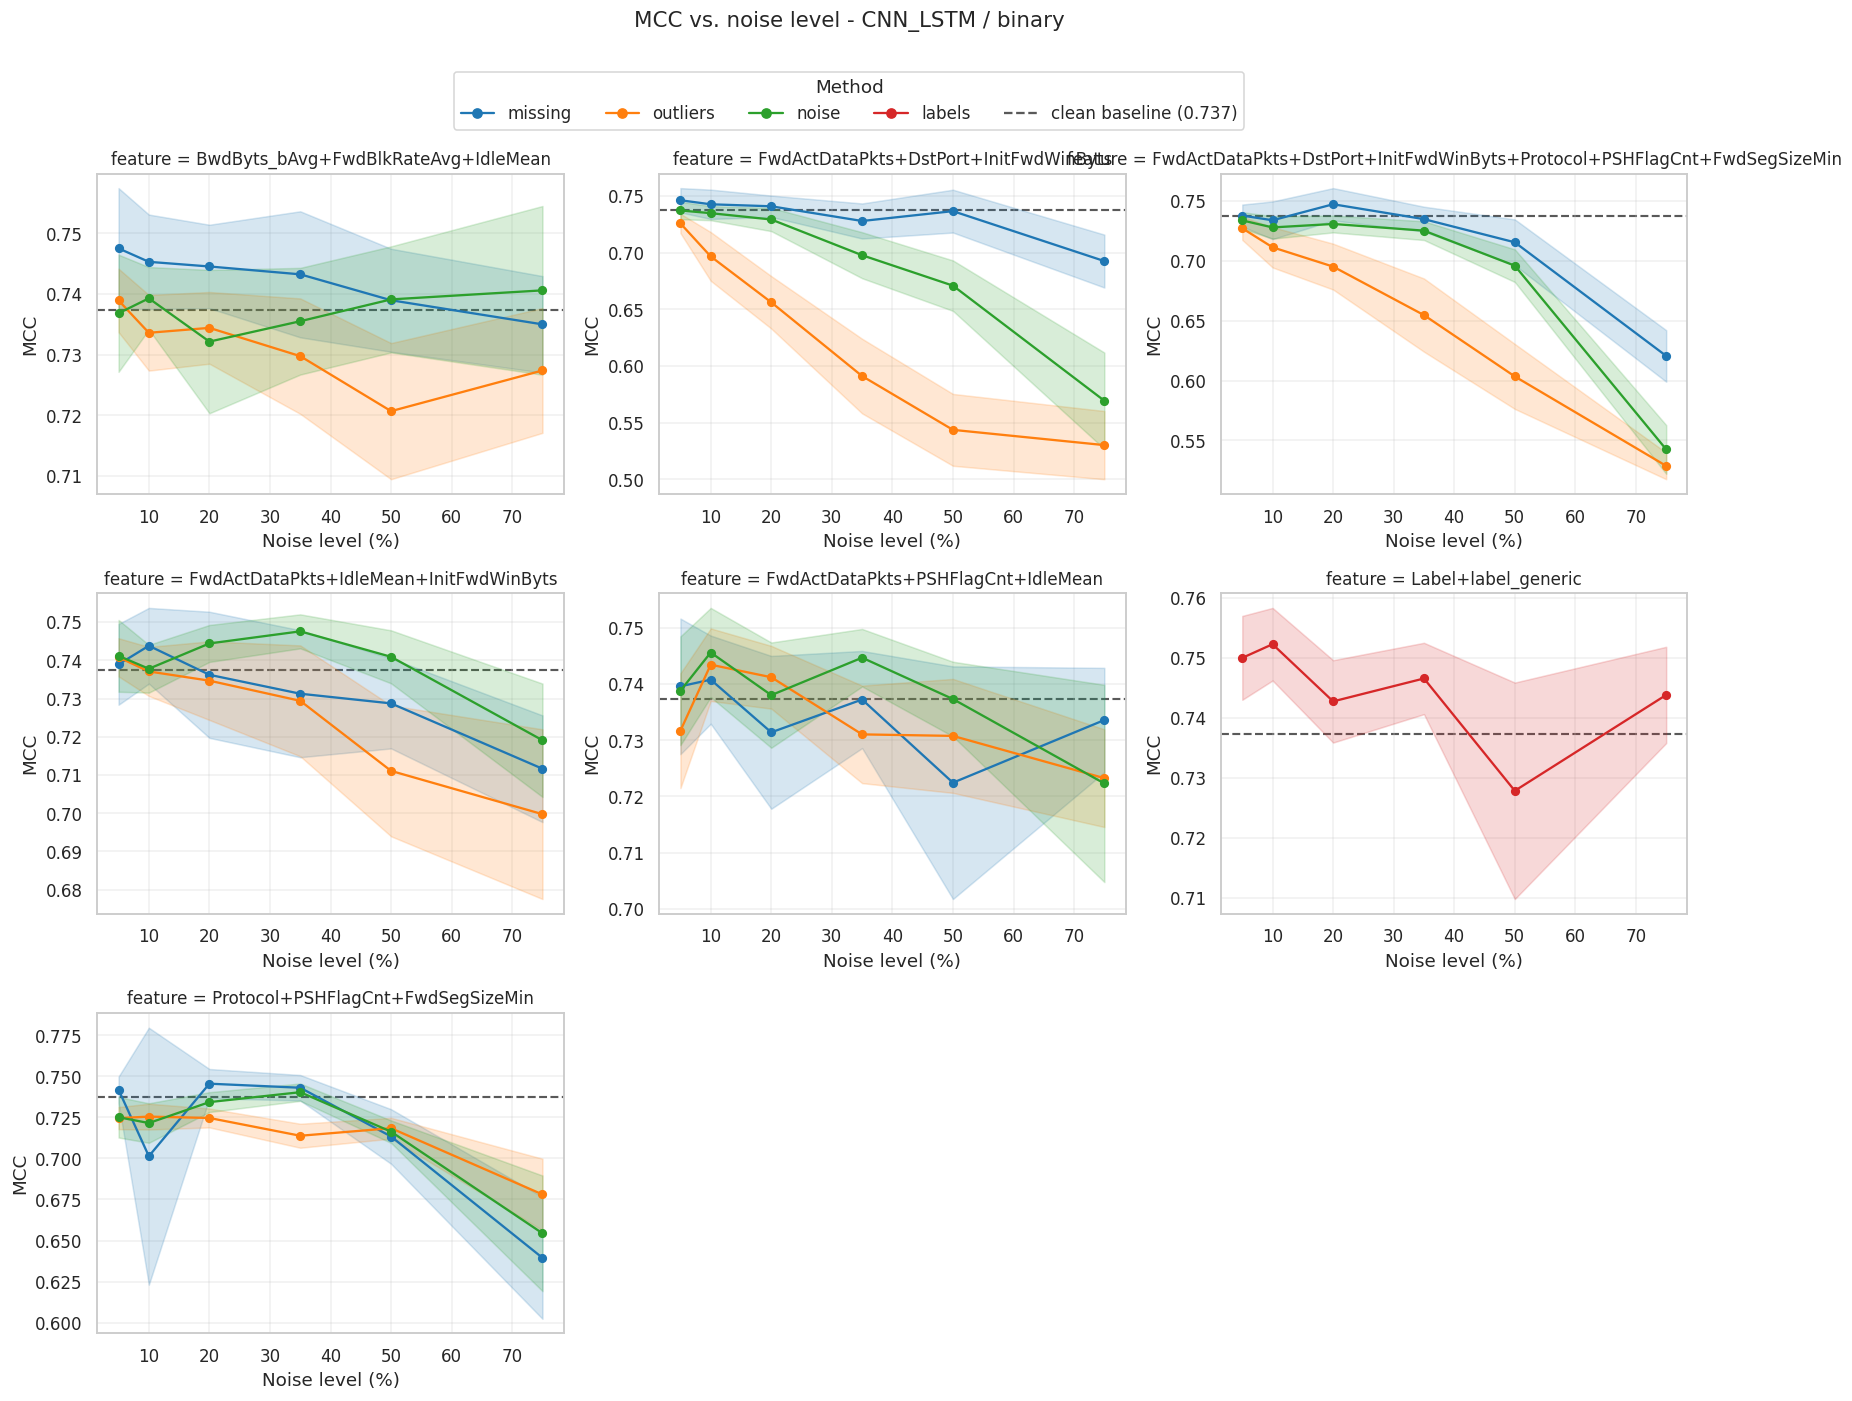

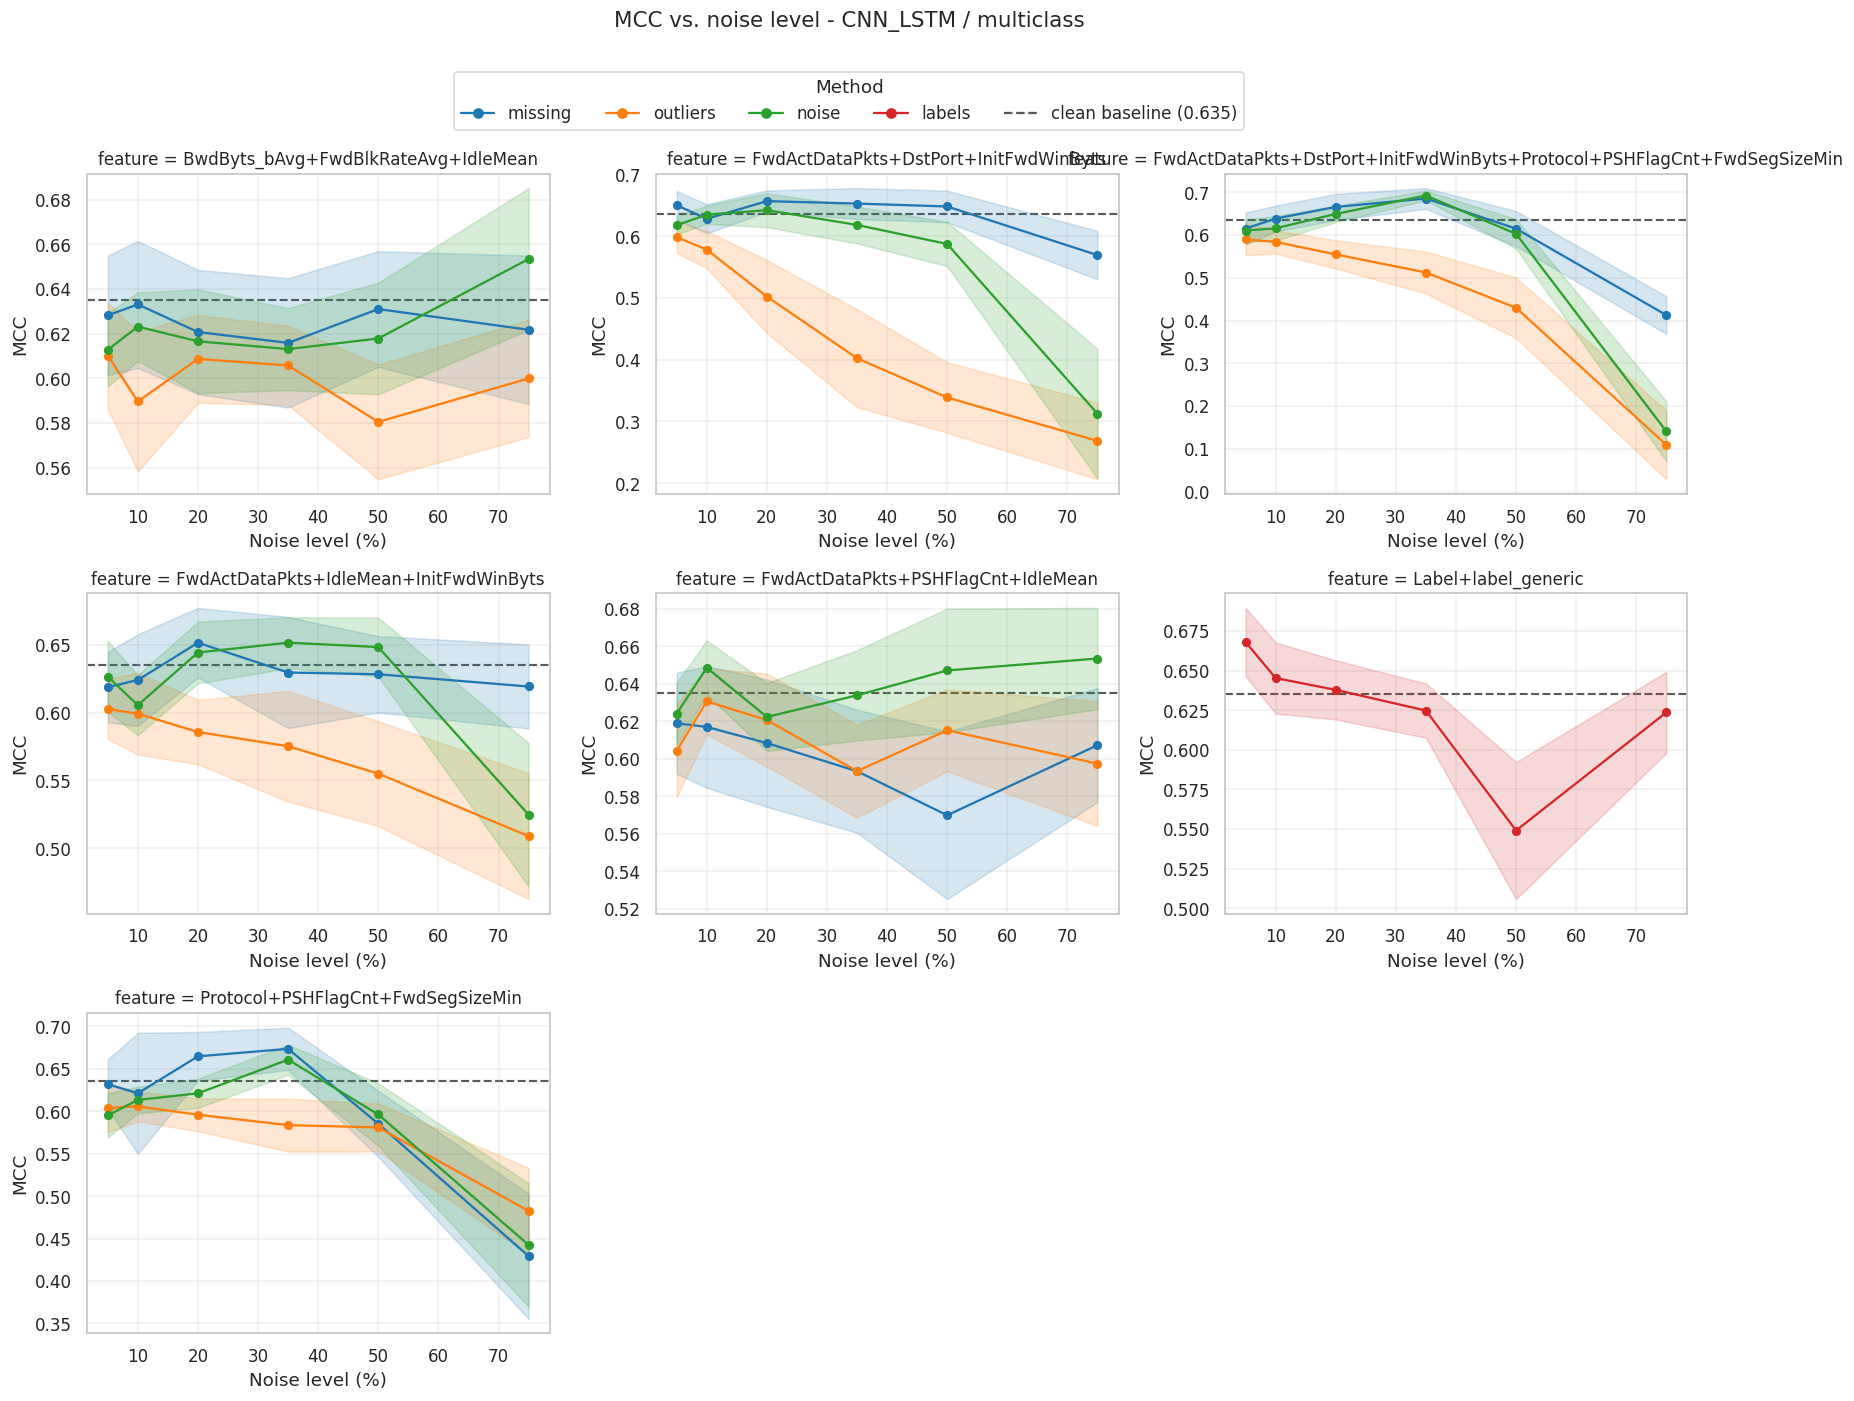

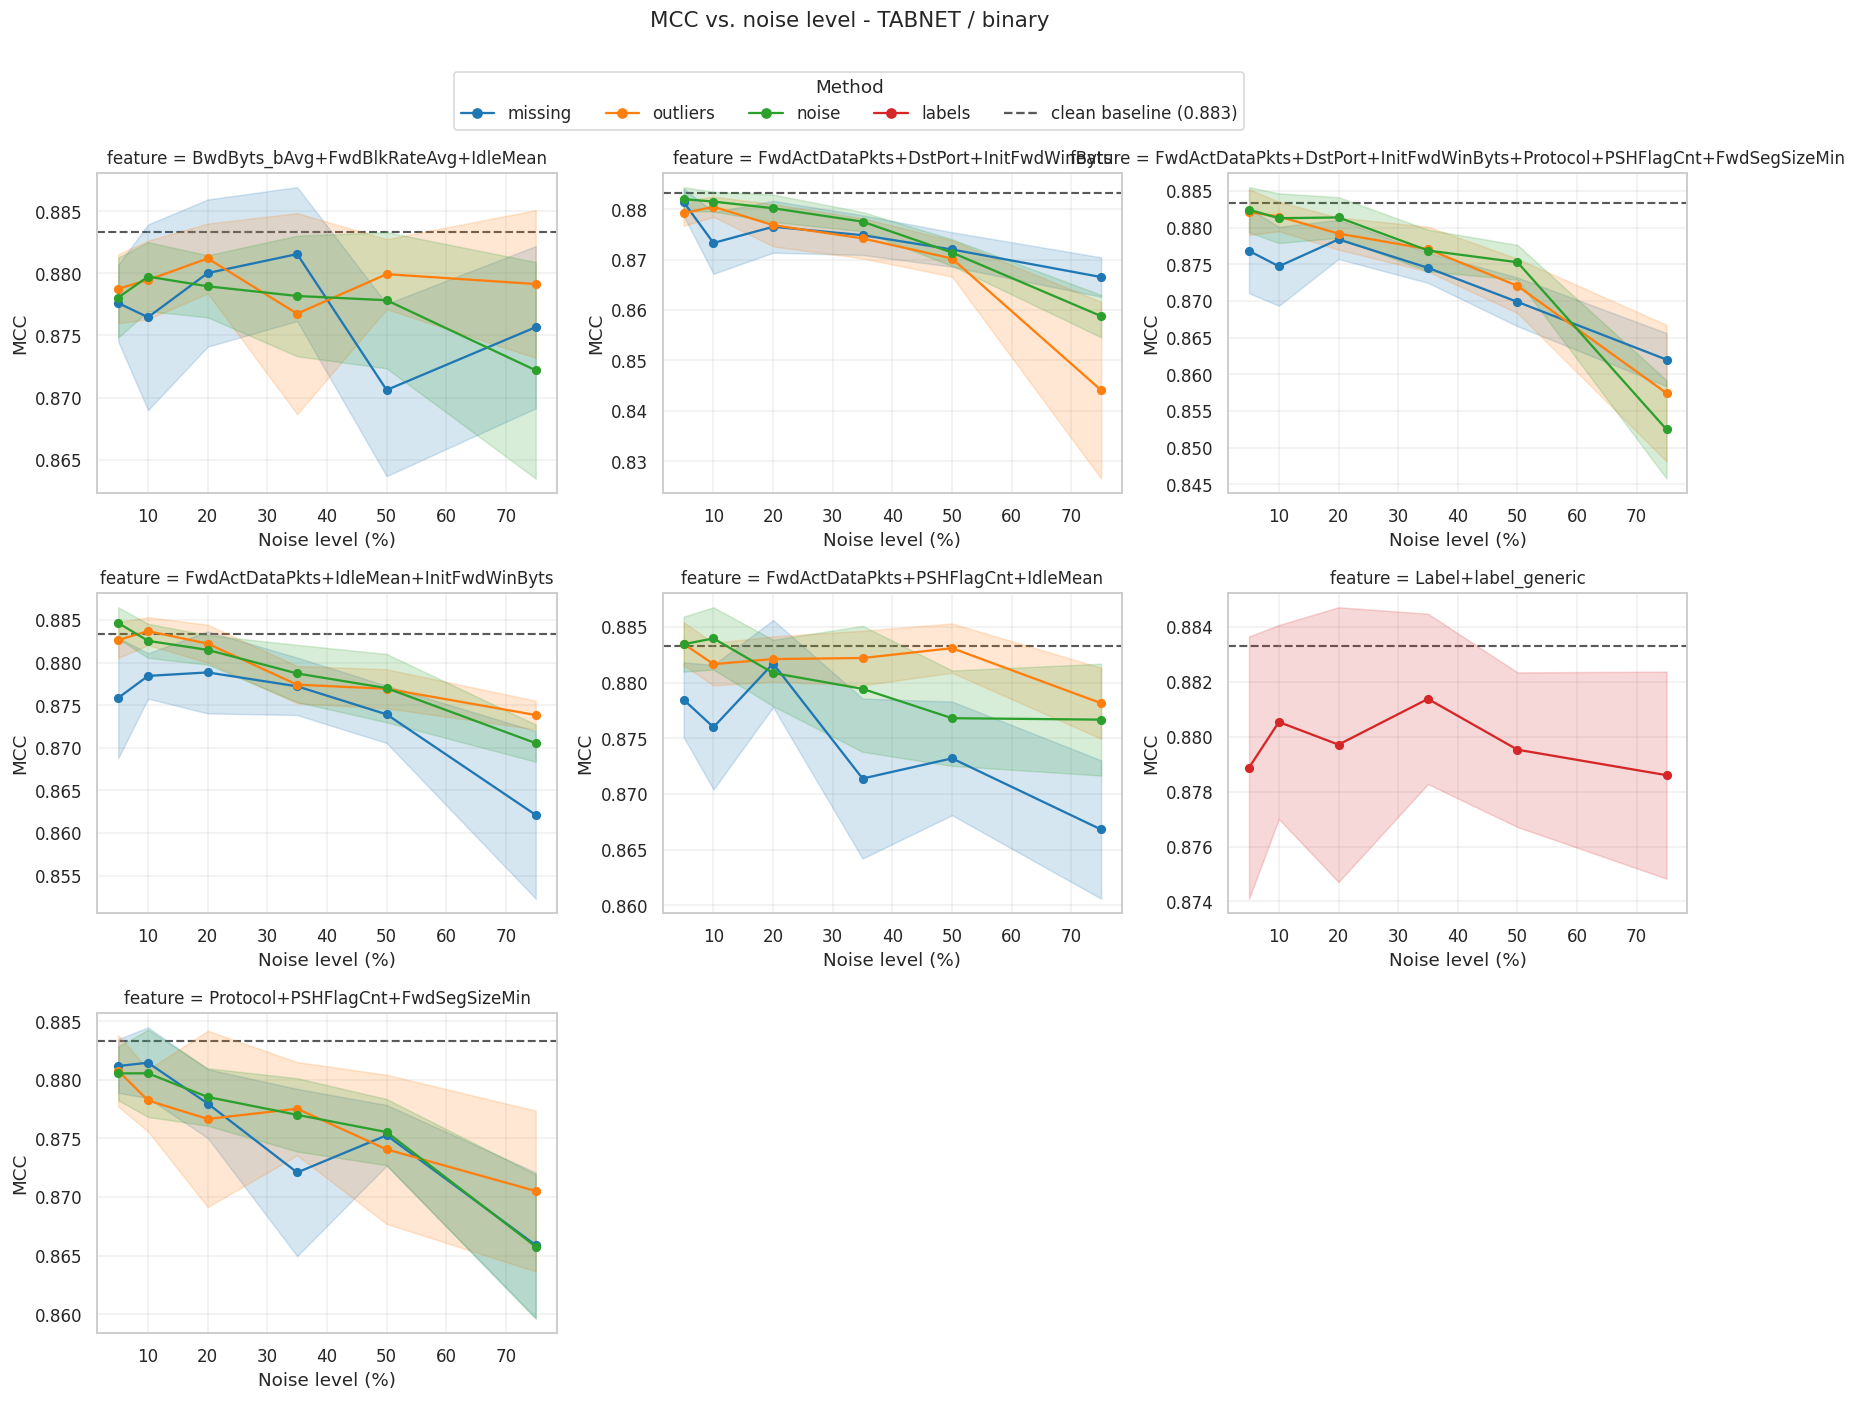

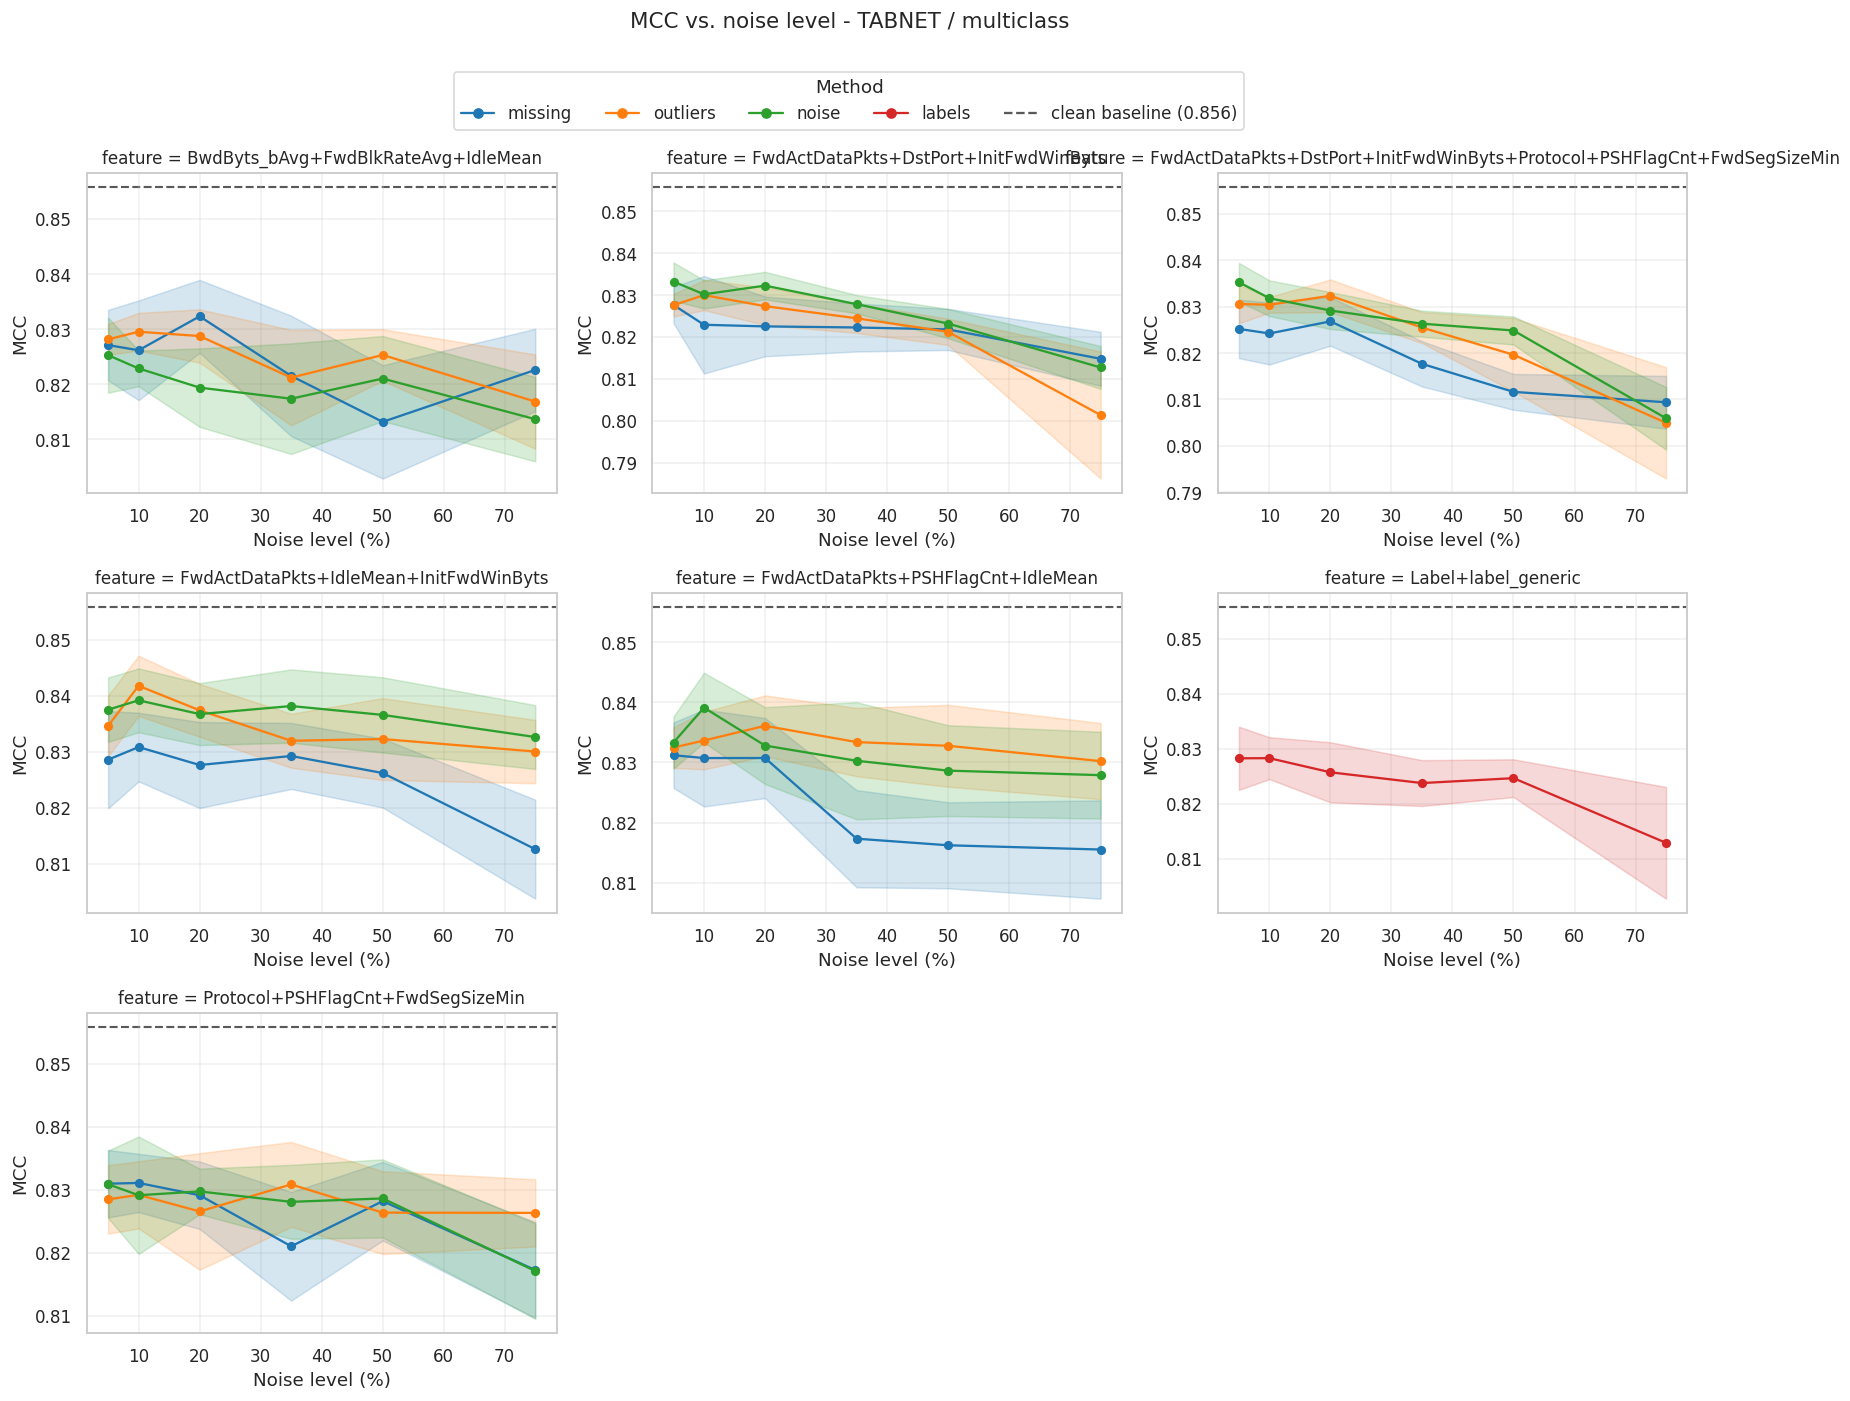

In [9]:
def trend_figs(metric):
    if not HAS_DATA:
        print("No data yet."); return
    for model in MODELS:
        for task in TASKS:
            save = (os.path.join(RESULTS_DIR, "figures",
                                 f"{metric}_{model}_{task}_by_feature.png")
                    if SAVE_FIGURES else None)
            fig = eu.plot_metric_vs_noise(df, model, task, metric,
                                          conf=CONF_LEVEL, facet_by="feature",
                                          hue="method", baselines=BL, savepath=save)
            if fig is not None:
                plt.show()

trend_figs("mcc")

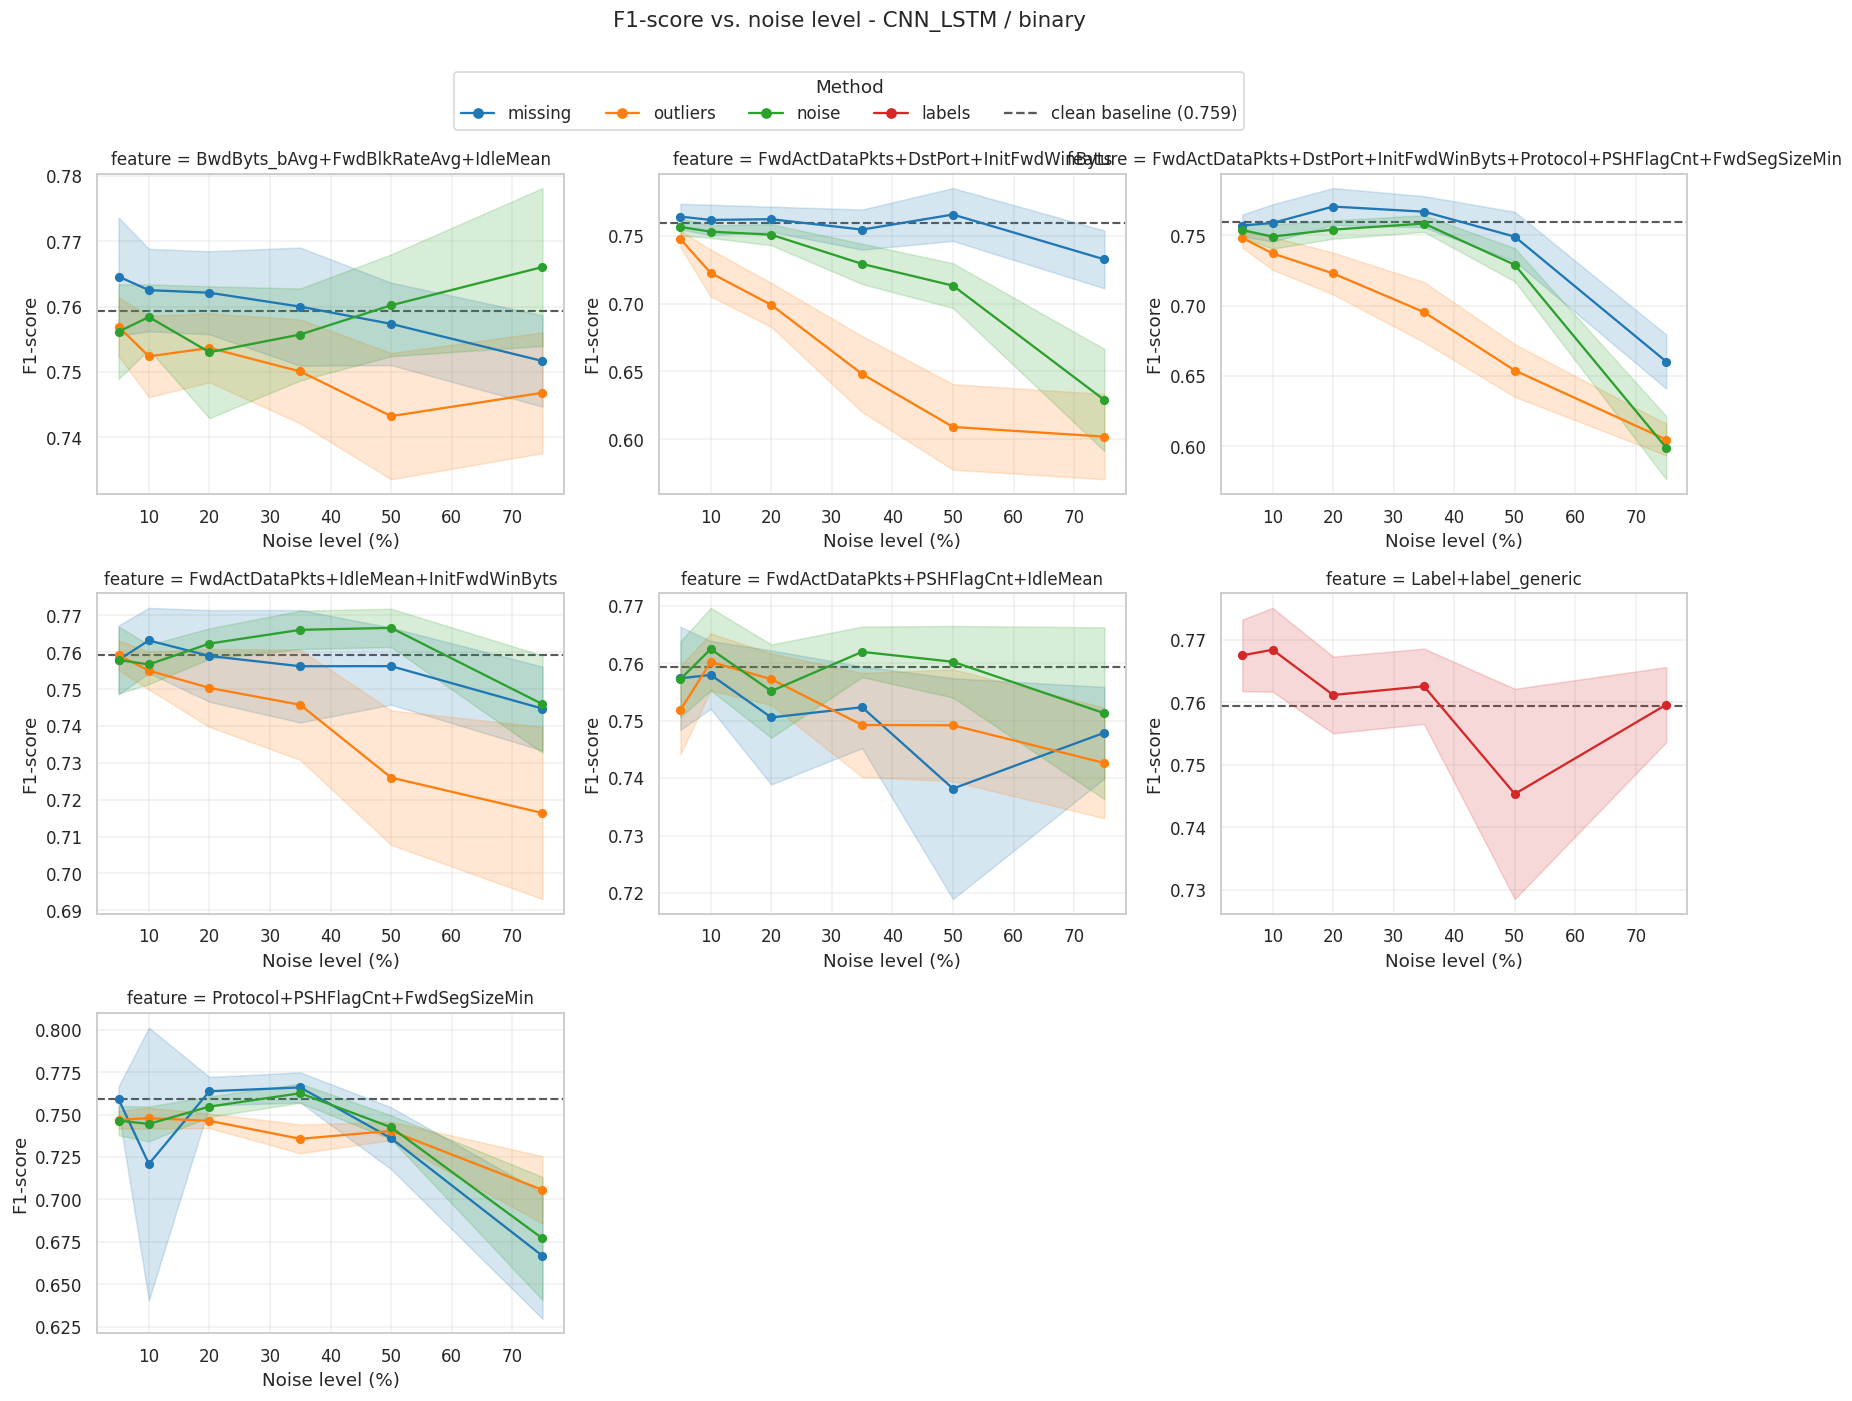

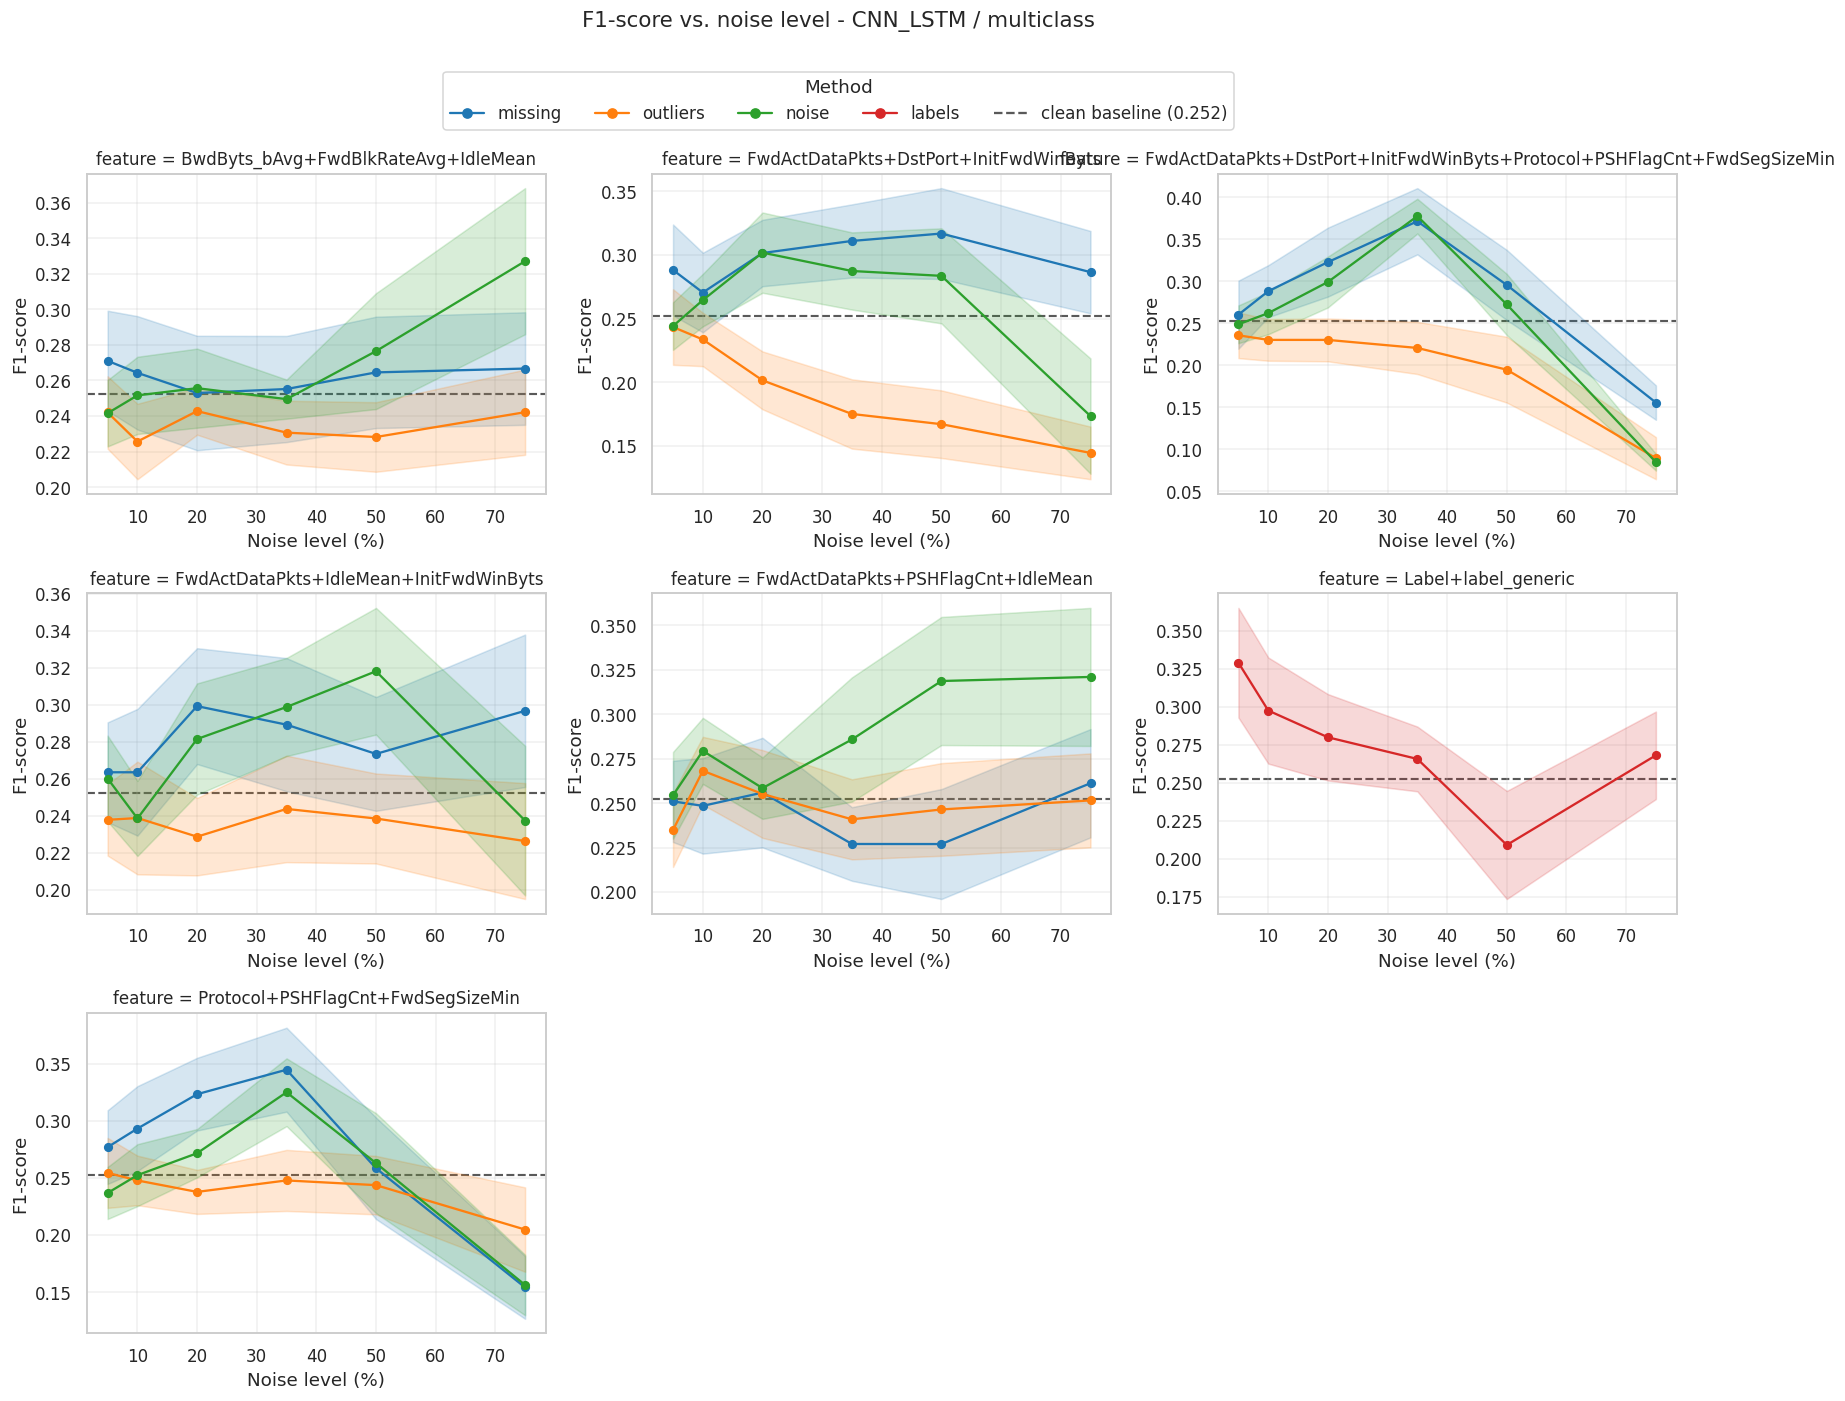

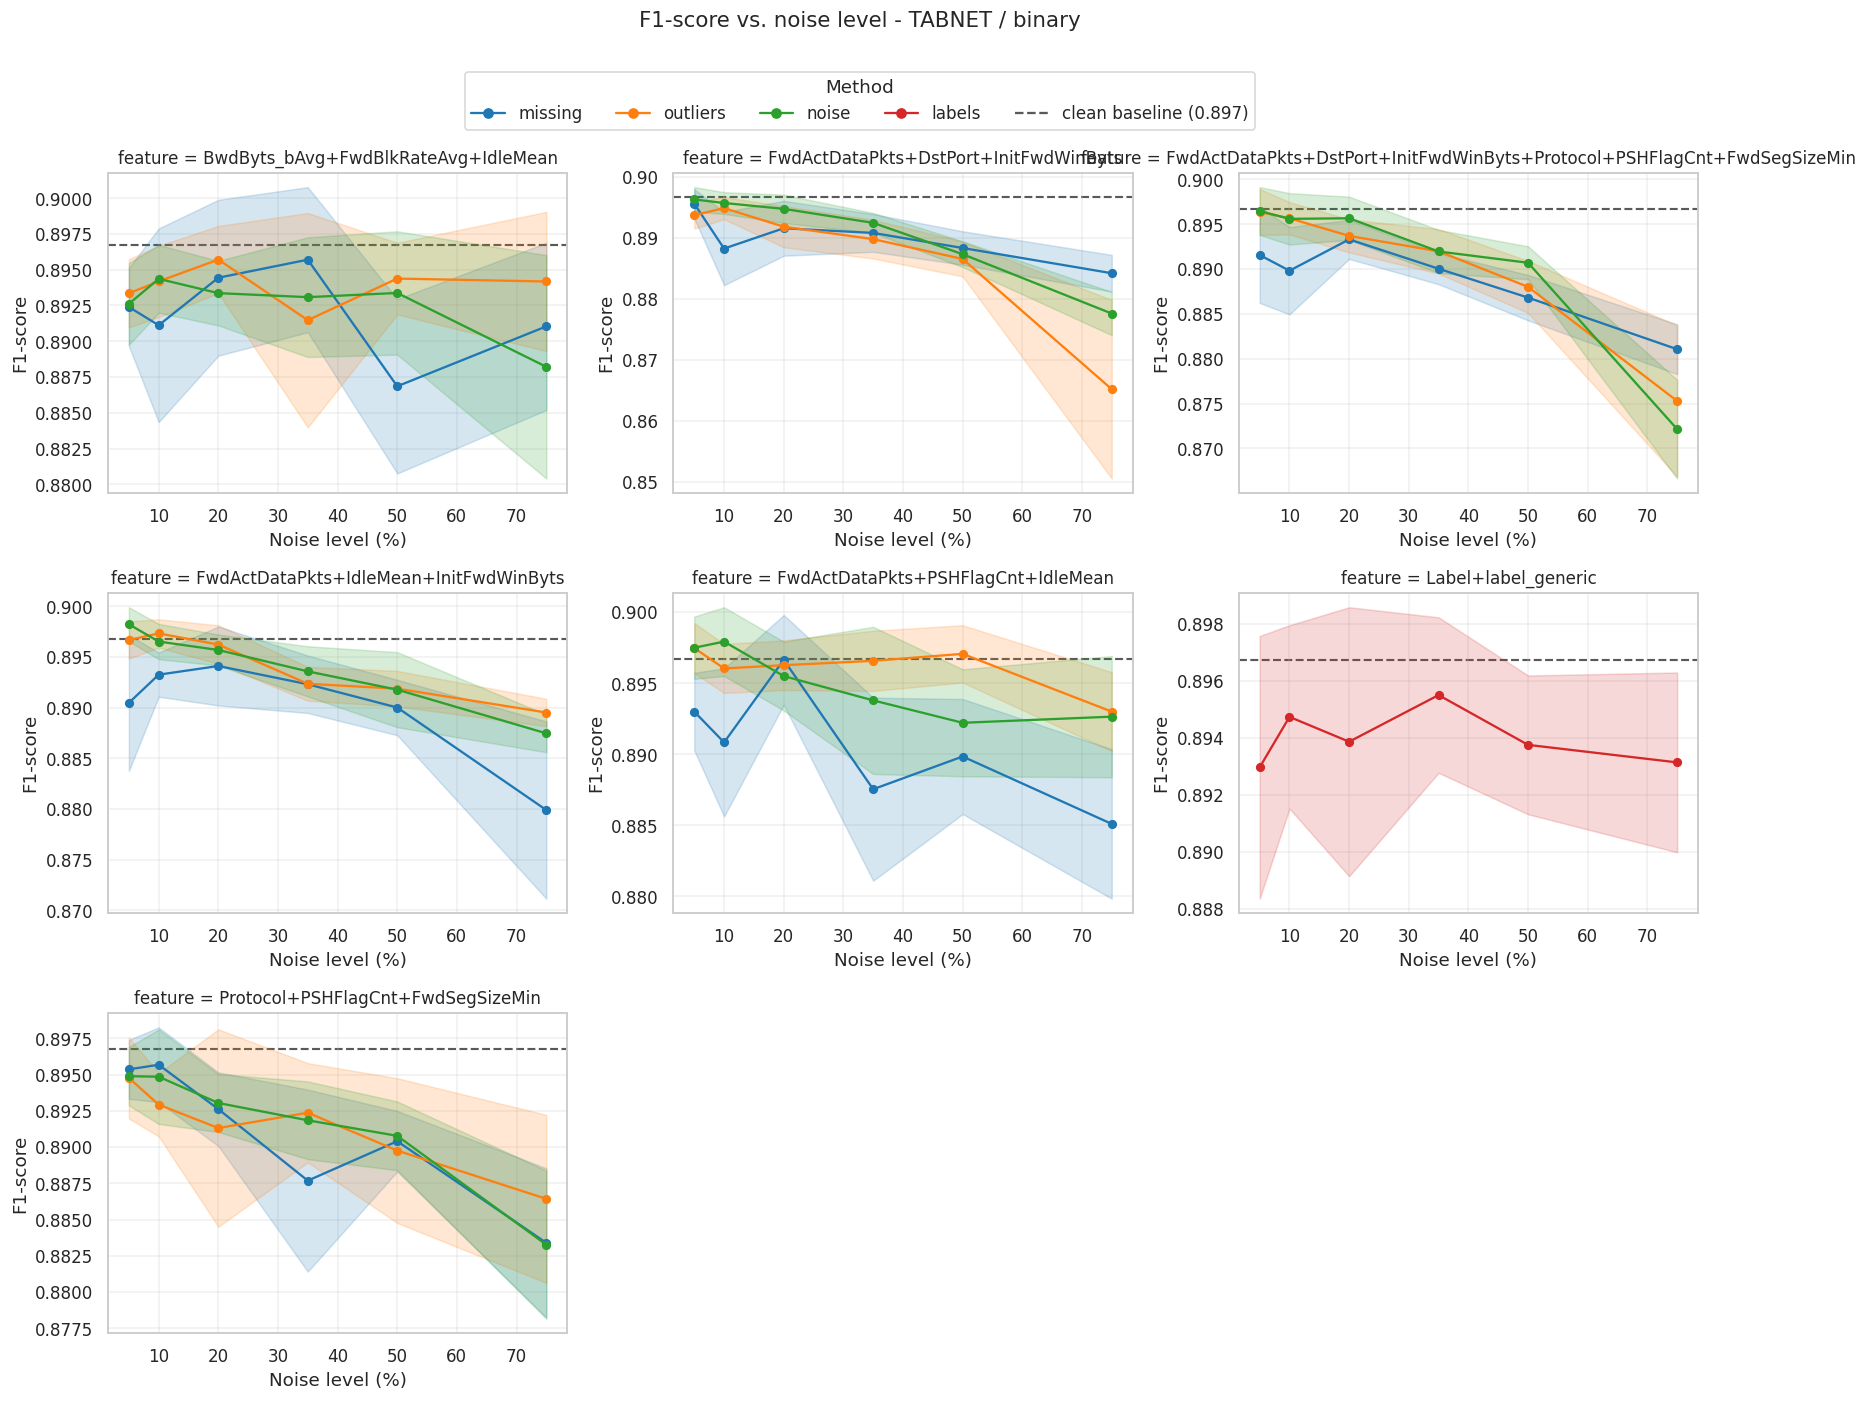

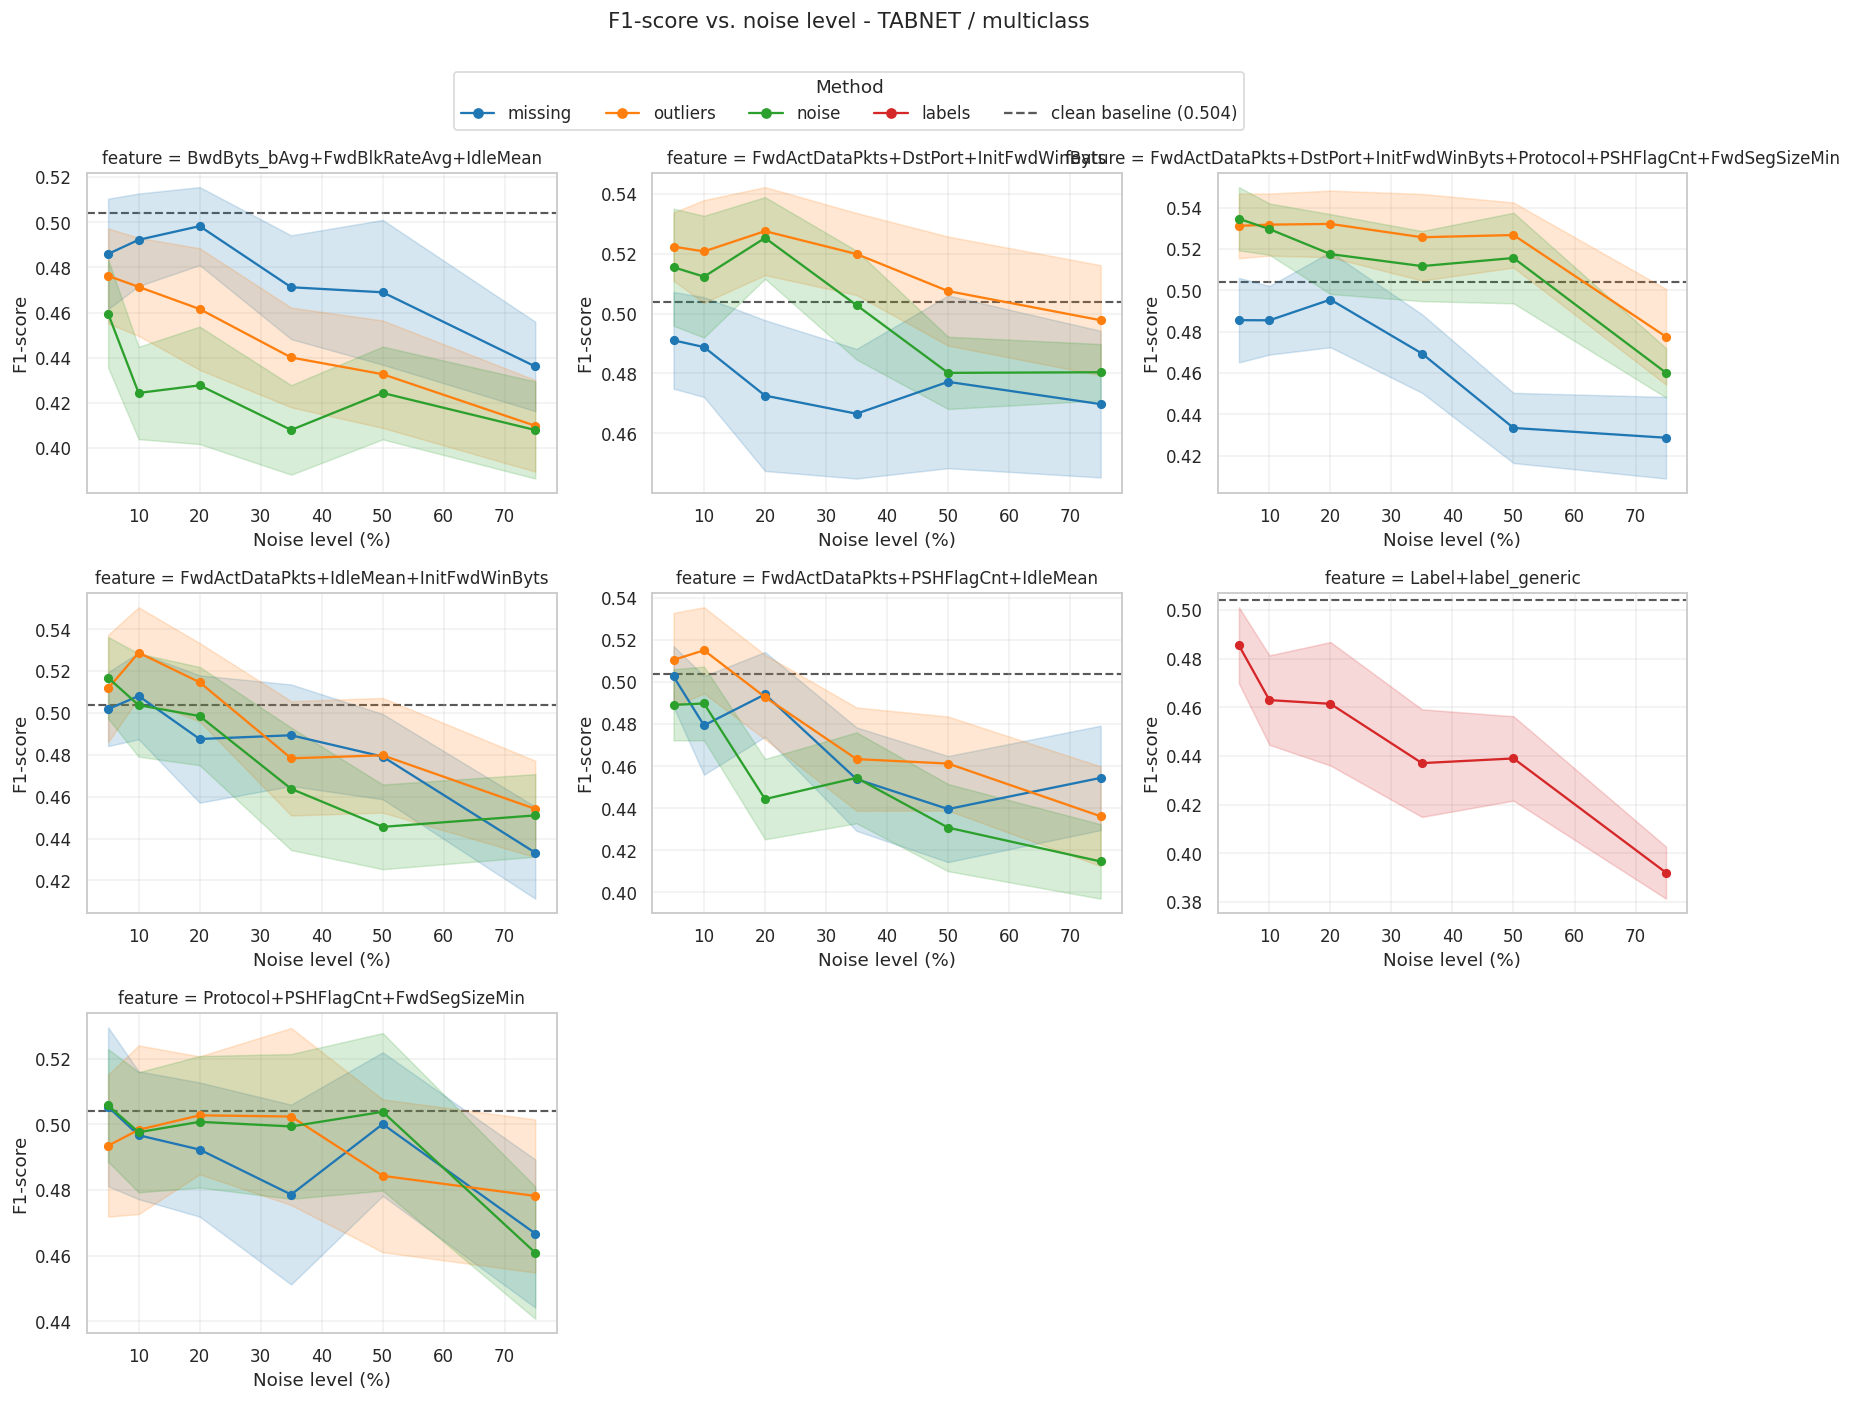

In [10]:
trend_figs("f1")

### Alternative view: one subplot per method, one line per feature

Swapping the facet and hue answers the dual question: *for a given corruption
method, which features are the most sensitive?* (shown for the binary task; edit
`task`/`metric` to explore).

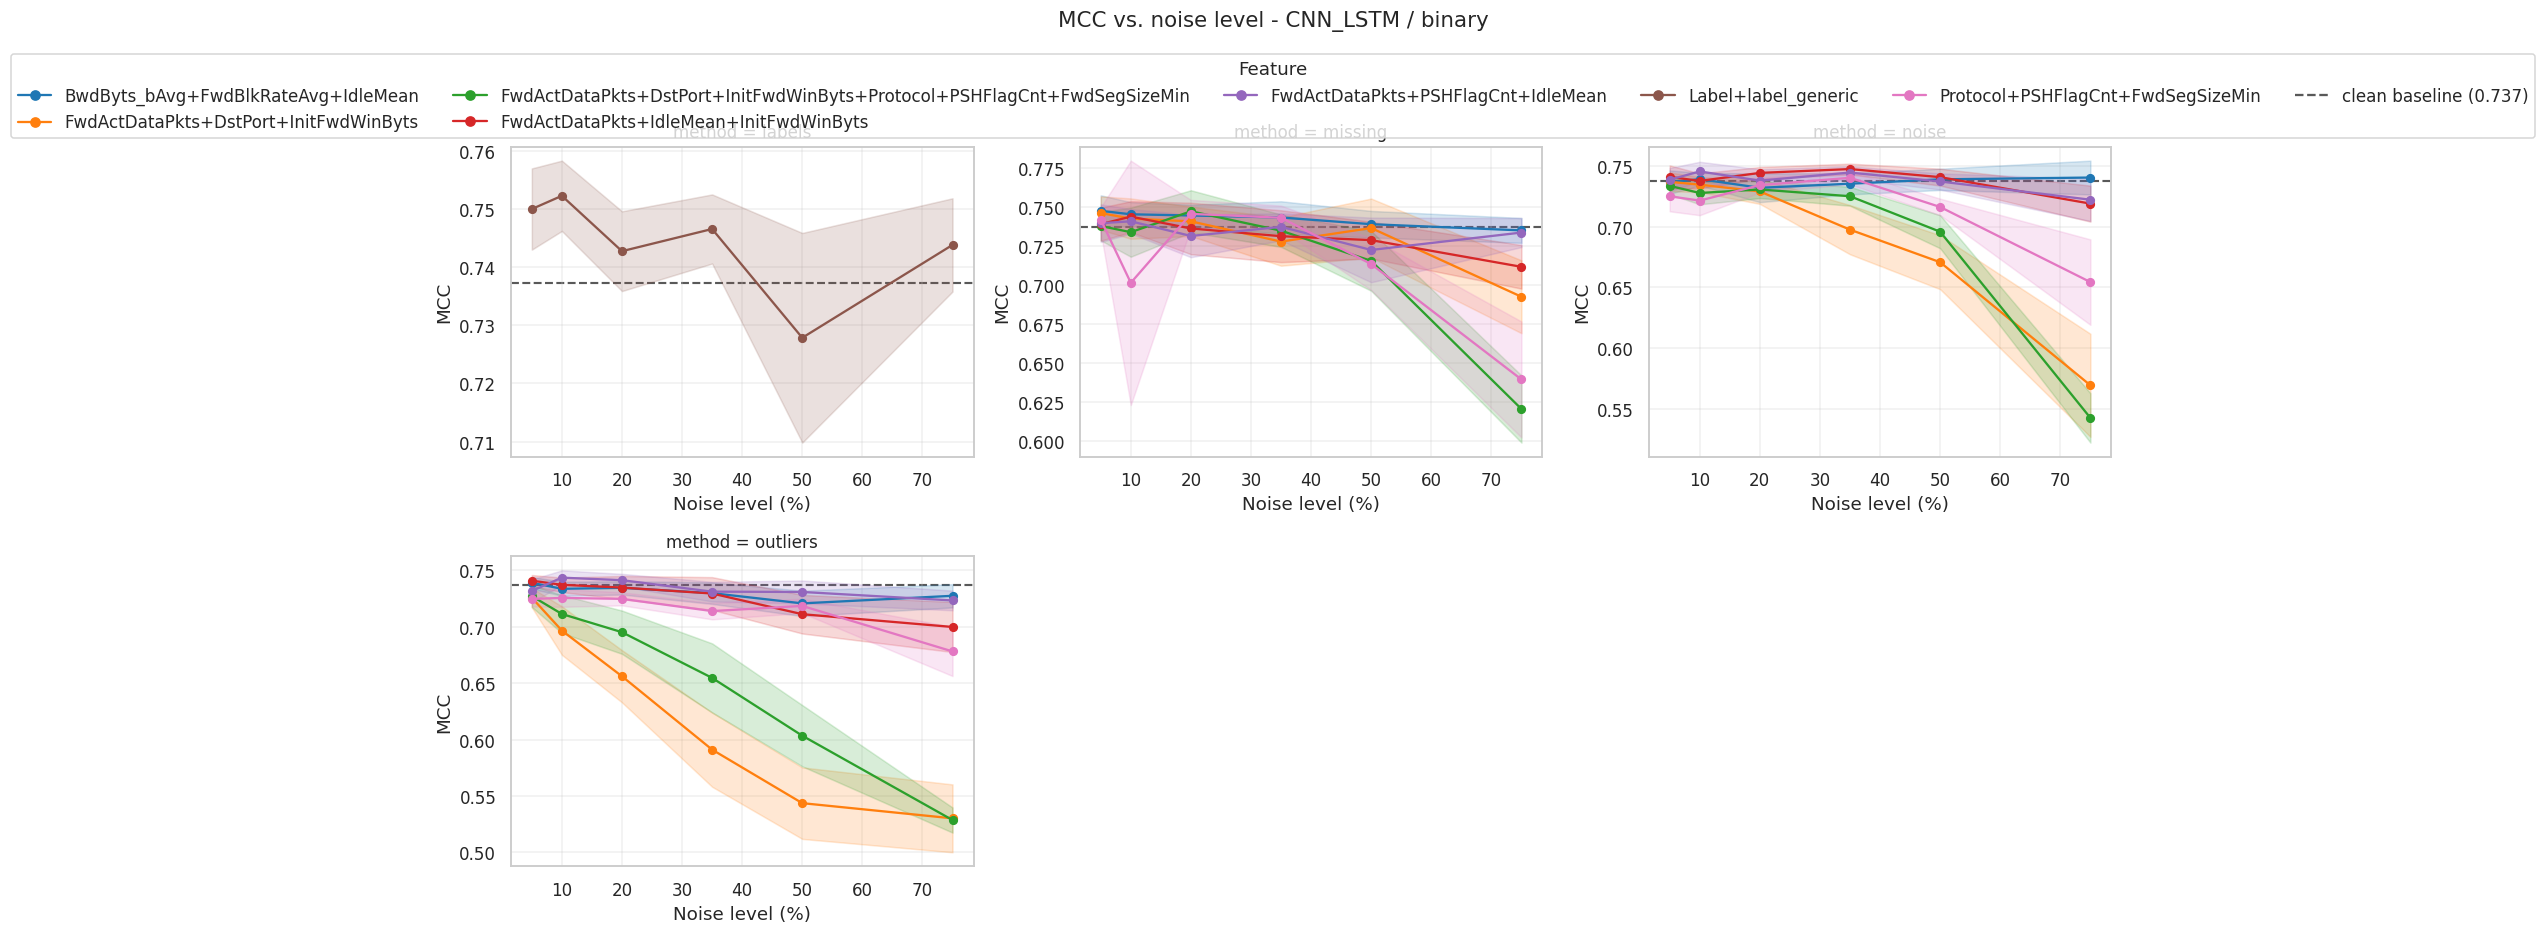

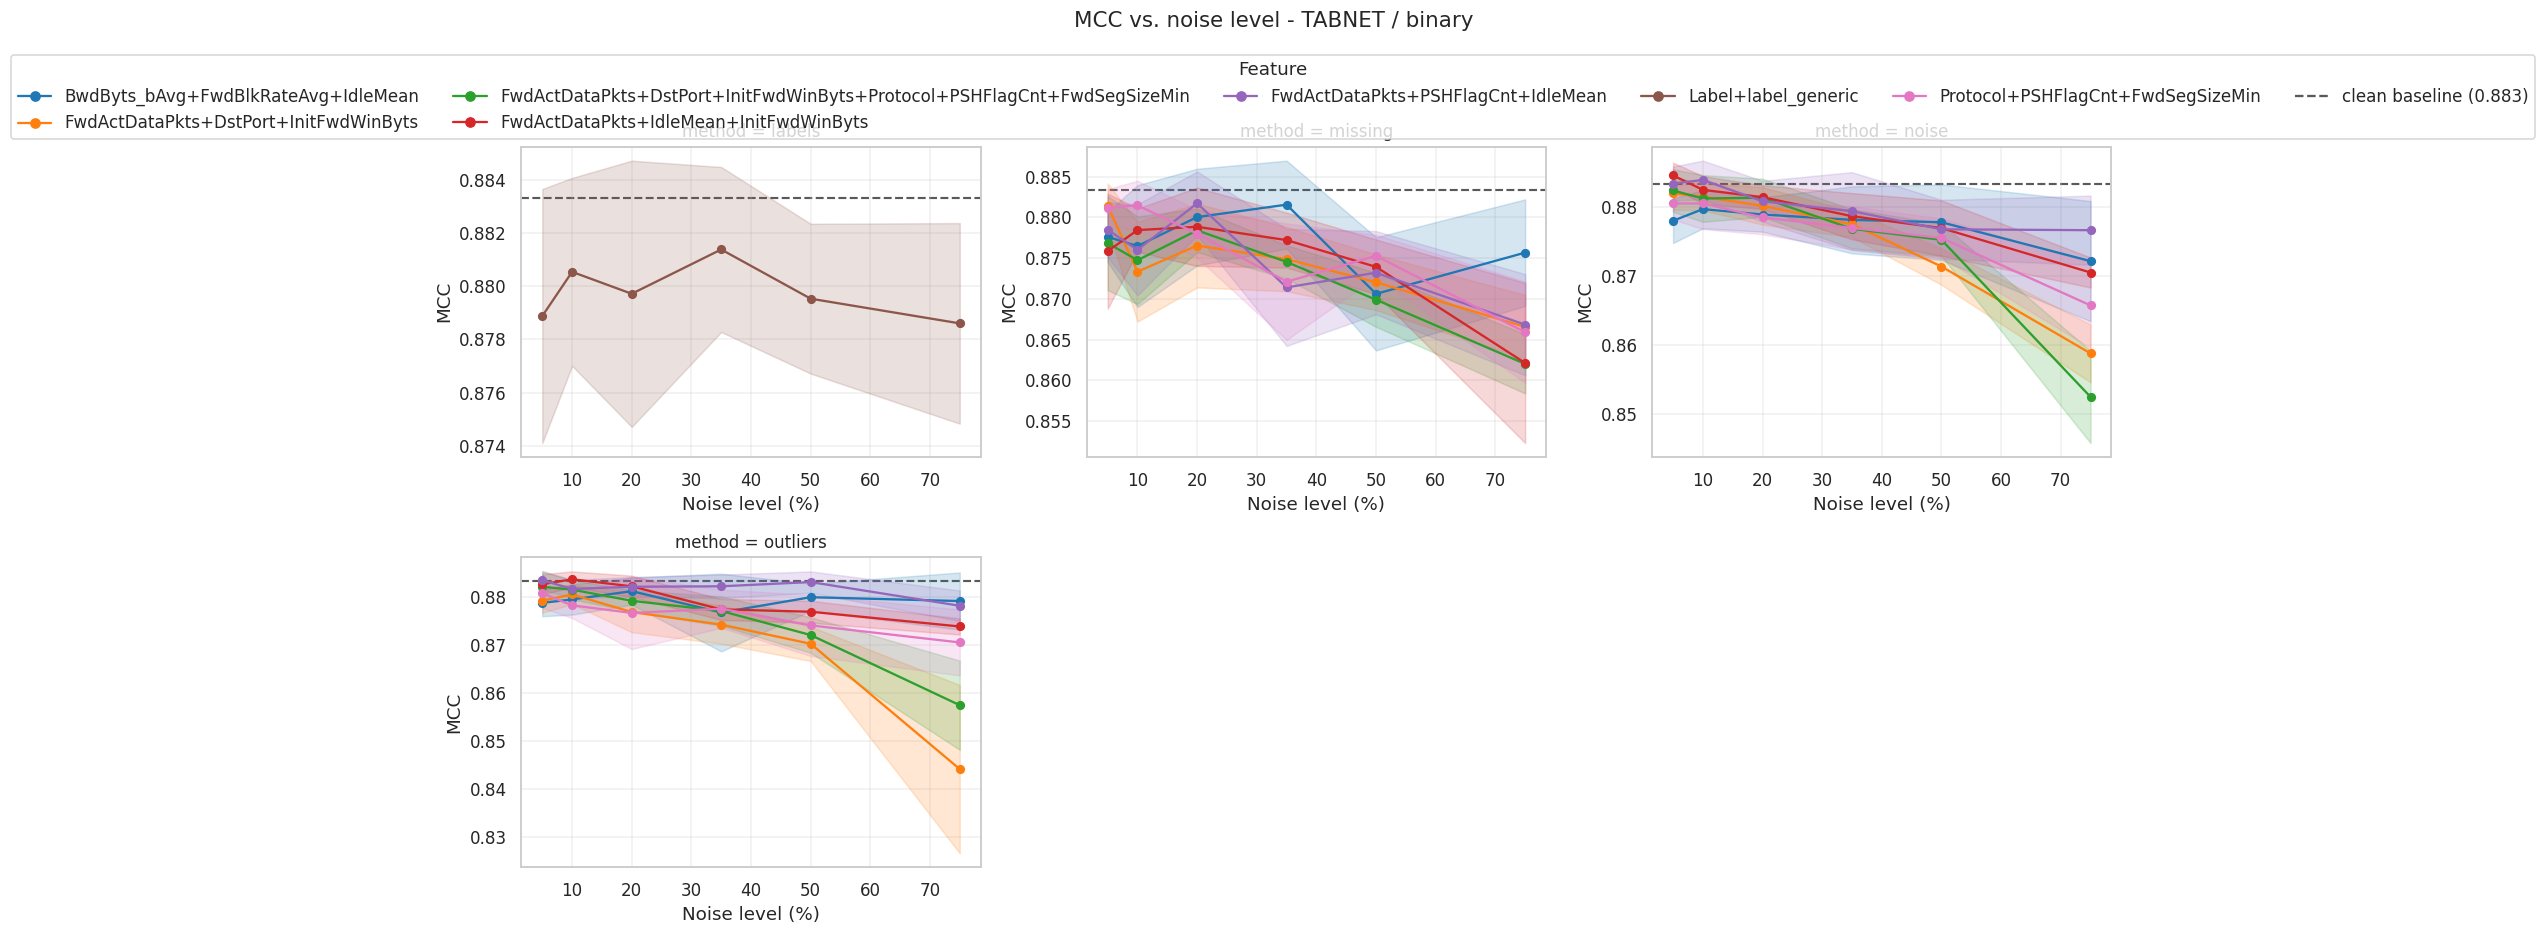

In [11]:
if HAS_DATA:
    for model in MODELS:
        fig = eu.plot_metric_vs_noise(df, model, "binary", "mcc",
                                      conf=CONF_LEVEL, facet_by="method",
                                      hue="feature", baselines=BL)
        if fig is not None:
            plt.show()

## 5. Heatmaps &mdash; method &times; noise level

Heatmaps condense the same information into compact, manuscript-friendly
figures. We show the **delta vs. the clean baseline** (diverging colour map
centred at zero): **blue = beats the clean model, red = worse than clean**. This
makes the "noise helped here" cells pop out at a glance.

> If the clean baseline is missing the function falls back to the lowest noise
> level as a proxy reference (`delta_vs_ref`).

Heatmaps show the change vs the CLEAN baseline (blue = beats clean).


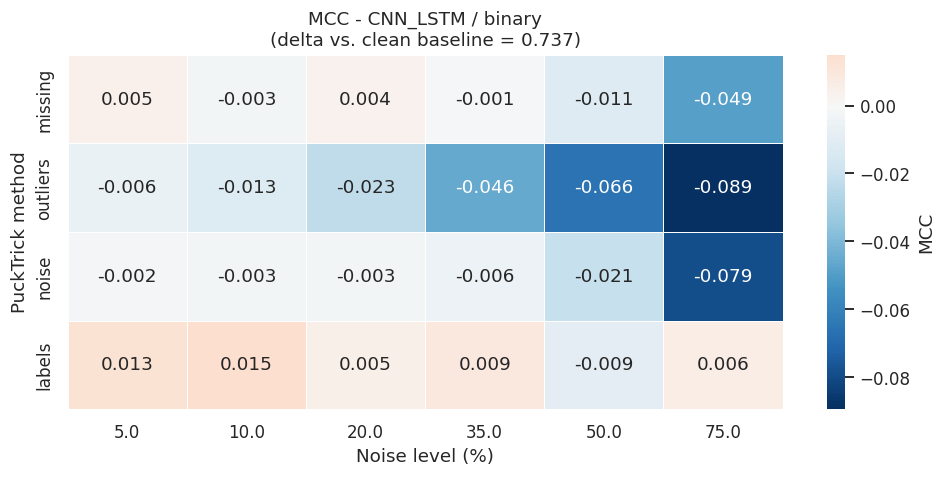

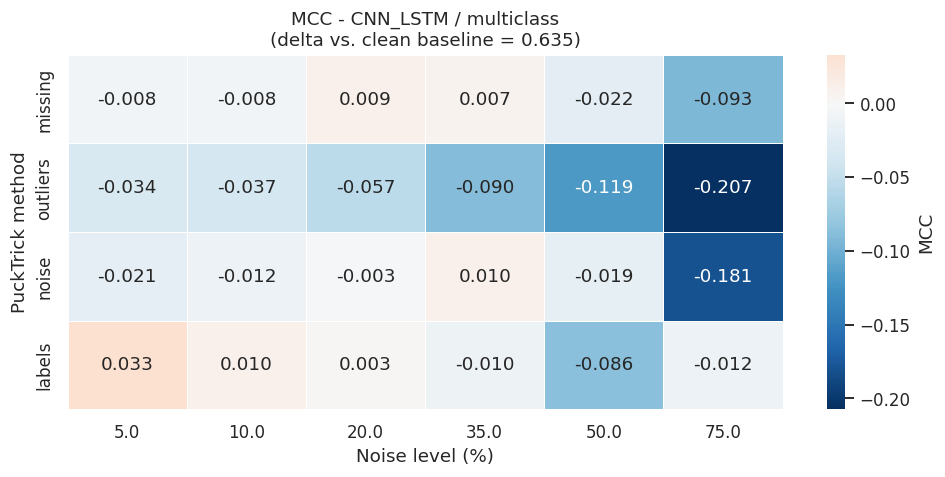

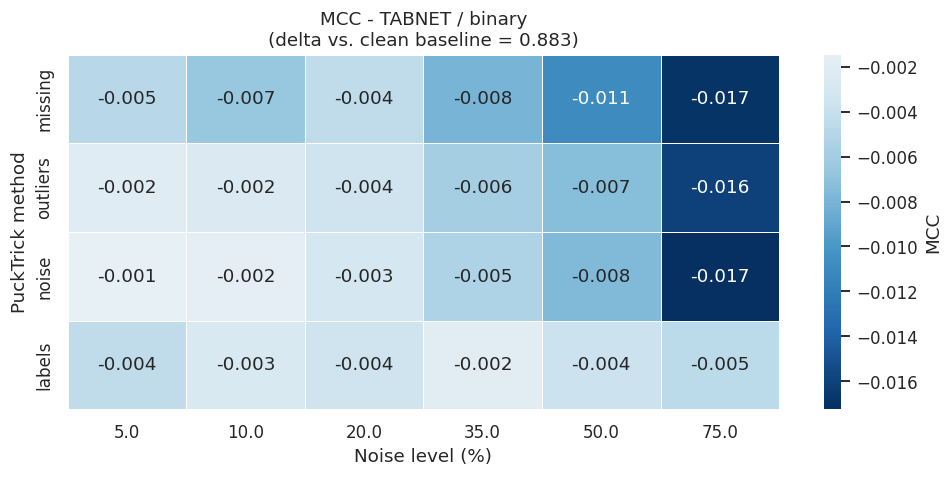

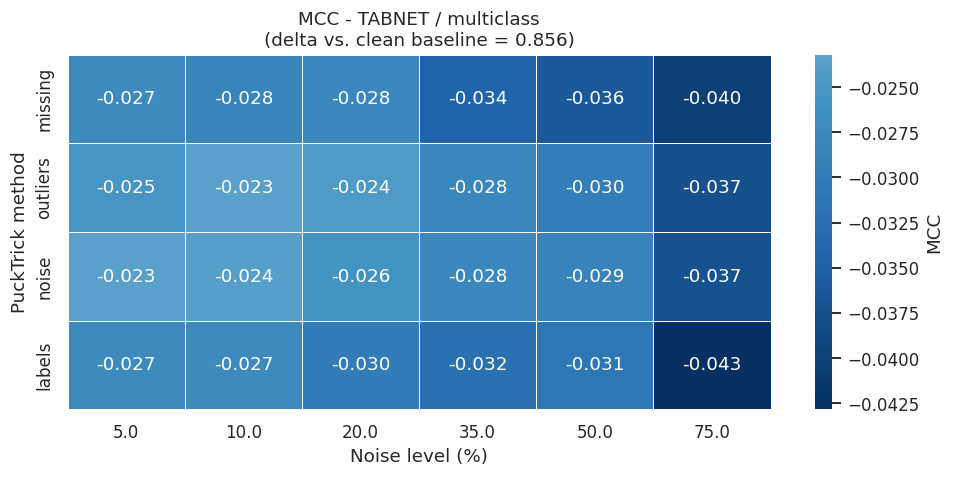

In [12]:
if HAS_DATA:
    if HAS_BASELINE:
        print("Heatmaps show the change vs the CLEAN baseline (blue = beats clean).")
    else:
        ref = eu.reference_level(df)
        print(f"No clean baseline; using lowest noise level {ref:g}% as proxy reference.")
    for model in MODELS:
        for task in TASKS:
            fig = eu.plot_metric_heatmap(df, model, task, "mcc",
                                         delta_vs_baseline=HAS_BASELINE, baselines=BL,
                                         delta_vs_ref=not HAS_BASELINE)
            if fig is not None:
                plt.show()

## 6. Is the change real? &mdash; significance tests

Overlapping error bars are not a verdict. We run **two complementary Wilcoxon
signed-rank tests**, both at the 5% level:

**(6a) vs. the clean baseline &mdash; the headline test.** For each
`(method, feature, noise%)` we test whether the per-seed metric values differ
from the **clean-baseline scalar** (one-sample Wilcoxon of `value - baseline`
against zero). This answers the thesis' core question directly: *does injecting
this noise beat (or hurt) the model trained on clean data?* The configurations
with `median_delta > 0` and `p < 0.05` are the defensible **"noise helped vs.
clean"** claims.

**(6b) vs. the lowest noise level &mdash; a within-grid trend check.** Pairs each
seed's metric with the *same seed's* metric at the lowest noise level. Pairing by
seed cancels seed-to-seed variance; it tells us whether *increasing* the noise
beyond the mildest setting moves the metric.

> With few seeds the test has limited power, so absence of significance is *not*
> evidence of no effect; always read it next to `n`.

In [13]:
# (6a) vs the CLEAN baseline -- the headline 'does noise beat clean?' test.
def baseline_significance(metric, task="binary"):
    if not (HAS_DATA and HAS_BASELINE):
        return pd.DataFrame()
    out = [eu.baseline_delta_significance(df, BL, m, task, metric) for m in MODELS]
    out = [o for o in out if not o.empty]
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

bsig_mcc = baseline_significance("mcc", task="binary")
if HAS_DATA and HAS_BASELINE and not bsig_mcc.empty:
    beats = bsig_mcc[(bsig_mcc["median_delta"] > 0) & (bsig_mcc["significant"])]
    print(f"Configurations that SIGNIFICANTLY BEAT the clean baseline "
          f"(binary MCC): {len(beats)} of {len(bsig_mcc)} tested")
    display(beats.sort_values("median_delta", ascending=False).reset_index(drop=True))
    print("\nConfigurations significantly WORSE than clean (for completeness):")
    worse = bsig_mcc[(bsig_mcc["median_delta"] < 0) & (bsig_mcc["significant"])]
    display(worse.sort_values("median_delta").head(20).reset_index(drop=True))
elif HAS_DATA and not HAS_BASELINE:
    print("No clean baseline available - skipping the vs-baseline test (see 6b).")

Configurations that SIGNIFICANTLY BEAT the clean baseline (binary MCC): 10 of 228 tested


,model,method,feature,noise_percentage,n,baseline,median_value,median_delta,mean_delta,p_value,significant
0,cnn_lstm,labels,Label+label_generic,10.0,20,0.737344,0.752862,0.015517,0.014942,0.000082,True
1,cnn_lstm,labels,Label+label_generic,35.0,20,0.737344,0.749945,0.012601,0.009232,0.004860,True
2,cnn_lstm,noise,FwdActDataPkts+IdleMean+InitFwdWinByts,35.0,20,0.737344,0.749756,0.012411,0.010233,0.000210,True
3,cnn_lstm,noise,FwdActDataPkts+PSHFlagCnt+IdleMean,35.0,20,0.737344,0.748379,0.011035,0.007353,0.008308,True
4,cnn_lstm,labels,Label+label_generic,5.0,20,0.737344,0.747983,0.010639,0.012667,0.000851,True
5,cnn_lstm,labels,Label+label_generic,75.0,20,0.737344,0.747610,0.010266,0.006490,0.048441,True
6,cnn_lstm,missing,FwdActDataPkts+DstPort+InitFwdWinByts,5.0,20,0.737344,0.747253,0.009908,0.008747,0.036234,True
7,cnn_lstm,noise,FwdActDataPkts+IdleMean+InitFwdWinByts,5.0,20,0.737344,0.744777,0.007432,0.003823,0.001017,True
8,cnn_lstm,noise,FwdActDataPkts+IdleMean+InitFwdWinByts,20.0,20,0.737344,0.743941,0.006596,0.007066,0.009436,True
9,tabnet,noise,FwdActDataPkts+IdleMean+InitFwdWinByts,5.0,20,0.883325,0.884700,0.001375,0.001307,0.044054,True



Configurations significantly WORSE than clean (for completeness):


,model,method,feature,noise_percentage,n,baseline,median_value,median_delta,mean_delta,p_value,significant
0,cnn_lstm,outliers,FwdActDataPkts+DstPort+InitFwdWinByts+Protocol...,75.0,20,0.737344,0.534875,-0.202469,-0.208662,0.000002,True
1,cnn_lstm,noise,FwdActDataPkts+DstPort+InitFwdWinByts+Protocol...,75.0,20,0.737344,0.538903,-0.198441,-0.194899,0.000002,True
2,cnn_lstm,outliers,FwdActDataPkts+DstPort+InitFwdWinByts,75.0,20,0.737344,0.547828,-0.189517,-0.207150,0.000002,True
3,cnn_lstm,outliers,FwdActDataPkts+DstPort+InitFwdWinByts,50.0,20,0.737344,0.551862,-0.185483,-0.193694,0.000002,True
4,cnn_lstm,outliers,FwdActDataPkts+DstPort+InitFwdWinByts,35.0,20,0.737344,0.590088,-0.147257,-0.146276,0.000002,True
5,cnn_lstm,outliers,FwdActDataPkts+DstPort+InitFwdWinByts+Protocol...,50.0,20,0.737344,0.593912,-0.143432,-0.133936,0.000002,True
6,cnn_lstm,noise,FwdActDataPkts+DstPort+InitFwdWinByts,75.0,20,0.737344,0.597989,-0.139356,-0.168014,0.000004,True
7,cnn_lstm,missing,FwdActDataPkts+DstPort+InitFwdWinByts+Protocol...,75.0,20,0.737344,0.622015,-0.115329,-0.116810,0.000002,True
8,cnn_lstm,noise,FwdActDataPkts+DstPort+InitFwdWinByts,50.0,20,0.737344,0.658298,-0.079047,-0.066554,0.000013,True
9,cnn_lstm,outliers,FwdActDataPkts+DstPort+InitFwdWinByts,20.0,20,0.737344,0.660615,-0.076729,-0.081265,0.000002,True


In [14]:
# (6b) vs the lowest noise level -- paired within-grid trend check.
def significance(metric, task="binary"):
    if not HAS_DATA:
        return pd.DataFrame()
    ref = eu.reference_level(df)
    out = []
    for model in MODELS:
        s = eu.paired_delta_significance(df, model, task, metric, ref)
        if not s.empty:
            s.insert(0, "model", model)
            out.append(s)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

sig_mcc = significance("mcc", task="binary")
if HAS_DATA and not sig_mcc.empty:
    ref = eu.reference_level(df)
    improved = sig_mcc[(sig_mcc["median_delta"] > 0) & (sig_mcc["significant"])]
    print(f"Significant MCC changes vs the {ref:g}% level (binary): "
          f"{len(improved)} improvements of {len(sig_mcc)} tested configs")
    display(improved.sort_values("median_delta", ascending=False).reset_index(drop=True))
elif HAS_DATA:
    print("Not enough paired data to run the within-grid test yet.")

Significant MCC changes vs the 5% level (binary): 2 improvements of 190 tested configs


,model,method,feature,noise_percentage,n_pairs,median_delta,mean_delta,p_value,significant
0,cnn_lstm,noise,Protocol+PSHFlagCnt+FwdSegSizeMin,35.0,20,0.006931,0.015255,0.007296,True
1,cnn_lstm,outliers,FwdActDataPkts+PSHFlagCnt+IdleMean,10.0,20,0.005228,0.011755,0.044054,True


## 7. Model comparison &mdash; TabNet vs. CNN-LSTM

Two complementary robustness summaries, averaged over all features/methods:

* **Mean metric across the whole noise grid** &mdash; overall quality under noise;
* **Degradation slope** &mdash; the linear trend of the metric vs. noise level
  (slope &approx; 0 &rarr; robust; strongly negative &rarr; fragile; positive
  &rarr; noise tends to help).

In [15]:
if HAS_DATA:
    rows = []
    for model in MODELS:
        for task in TASKS:
            sub = df[(df.model == model) & (df.task == task)]
            for metric in ["mcc", "f1"]:
                per_level = (sub.groupby("noise_percentage")[metric]
                               .mean().reset_index().dropna())
                slope = np.nan
                if len(per_level) >= 2:
                    slope = np.polyfit(per_level["noise_percentage"],
                                       per_level[metric], 1)[0]
                rows.append({"model": model, "task": task, "metric": metric,
                             "mean_over_grid": sub[metric].mean(),
                             "slope_per_pct": slope})
    comp = pd.DataFrame(rows)
    display(comp.pivot_table(index=["task", "metric"], columns="model",
                             values=["mean_over_grid", "slope_per_pct"]))

mean_over_grid           slope_per_pct          
model                   cnn_lstm    tabnet      cnn_lstm    tabnet
task       metric                                                 
binary     f1           0.740472  0.891690     -0.000722 -0.000142
           mcc          0.716037  0.876536     -0.000931 -0.000181
multiclass f1           0.255980  0.480565     -0.000499 -0.000752
           mcc          0.588166  0.826301     -0.001814 -0.000191

## 8. Per-class behaviour (multiclass)

The macro MCC/F1 can mask what happens to individual **attack classes**, some
of which are rare. The artifacts do not store a per-class report, but they do
store the multiclass confusion matrix (`cm_mul`), from which per-class
precision/recall/F1 follow directly. Here we check which classes gain or lose F1
as noise increases &mdash; important because an IDS that improves overall while
collapsing on a rare-but-critical attack is *not* an improvement in practice.
(Classes are identified by integer index, since names are not stored.)

In [16]:
pcd = eu.per_class_dataframe(ROOT_DIR)
if SCENARIO is not None and not pcd.empty:
    pcd = pcd[pcd["scenario"] == SCENARIO]
if pcd.empty:
    print("No per-class data available yet.")
else:
    ref = eu.reference_level(df)
    hi = sorted(pcd["noise_percentage"].dropna().unique())[-1]
    piv = (pcd[pcd["noise_percentage"].isin([ref, hi])]
           .groupby(["model", "class", "noise_percentage"])["f1"].mean()
           .unstack("noise_percentage"))
    if ref in piv.columns and hi in piv.columns:
        piv["delta(F1)"] = piv[hi] - piv[ref]
        piv = piv.rename(columns={ref: f"F1@{ref:g}%", hi: f"F1@{hi:g}%"})
        print(f"Per-class F1 (mean over methods/features): reference {ref:g}% -> highest {hi:g}% noise")
        display(piv.sort_values("delta(F1)").round(4))

Per-class F1 (mean over methods/features): reference 5% -> highest 75% noise


noise_percentage   F1@5%  F1@75%  delta(F1)
model    class                             
tabnet   10       0.6339  0.5004    -0.1335
cnn_lstm 1        0.7896  0.6748    -0.1148
tabnet   9        0.5525  0.4629    -0.0895
cnn_lstm 3        0.7533  0.6757    -0.0777
tabnet   11       0.7506  0.6988    -0.0517
         2        0.5997  0.5760    -0.0237
         4        0.9858  0.9706    -0.0152
cnn_lstm 0        0.9598  0.9454    -0.0143
tabnet   8        0.5868  0.5791    -0.0076
         1        0.9899  0.9841    -0.0058
         5        0.7265  0.7217    -0.0048
         0        0.9807  0.9788    -0.0019
         3        0.8877  0.8895     0.0017
cnn_lstm 8        0.6712  0.6762     0.0050
tabnet   6        0.6357  0.6441     0.0084
cnn_lstm 9        0.1181  0.1294     0.0113
         2        0.0226  0.0357     0.0131
         5        0.3031  0.3164     0.0133
         6        0.3506  0.3994     0.0488
tabnet   7        0.0150  0.0698     0.0549
cnn_lstm 4        0.0602  0.2152     0.1550
         7           NaN     NaN        NaN
         10          NaN  0.0941        NaN
         11          NaN     NaN        NaN
         12          NaN     NaN        NaN
         13          NaN     NaN        NaN
tabnet   12          NaN     NaN        NaN
         13          NaN     NaN        NaN
         14          NaN     NaN        NaN

## 9. Feature-importance drift

A mechanistic check: when PuckTrick corrupts a feature, does the model's
**permutation importance** for that feature drop (it learns to ignore the
unreliable signal) or stay high (it keeps relying on noise)? We track the mean
importance of the *corrupted* feature as the noise level grows. (`is_corrupted`
is name-normalised, so the file's `Down_Up Ratio` matches the importance dict's
`Down/Up Ratio`.)

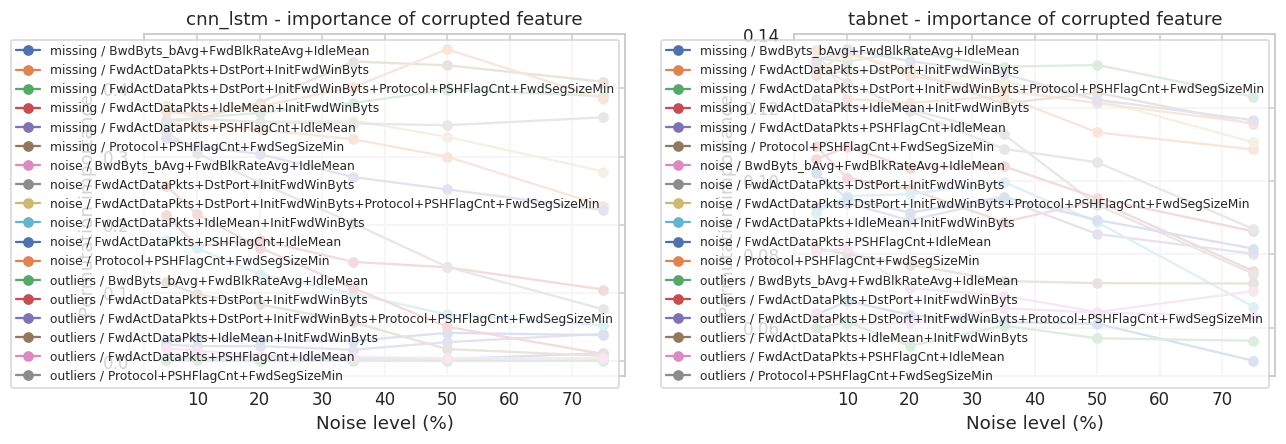

In [17]:
fid = eu.feature_importance_dataframe(ROOT_DIR)
if SCENARIO is not None and not fid.empty:
    fid = fid[fid["scenario"] == SCENARIO]
if fid.empty:
    print("No feature-importance data available yet.")
else:
    self_imp = fid[fid["is_corrupted"]]
    if self_imp.empty:
        print("Corrupted feature not found among reported importances "
              "(e.g. row-level 'duplicated'/'labels' runs); showing top features instead.")
        top = (fid.groupby(["model", "fi_feature"])["importance"].mean()
                  .reset_index().sort_values("importance", ascending=False))
        display(top.groupby("model").head(8).reset_index(drop=True))
    else:
        tab = (self_imp.groupby(["model", "method", "corrupted_feature",
                                 "noise_percentage"])["importance"]
                       .mean().reset_index())
        models_here = sorted(tab["model"].dropna().unique())
        fig, axes = plt.subplots(1, len(models_here),
                                 figsize=(6 * len(models_here), 4.2), squeeze=False)
        for ax, model in zip(axes[0], models_here):
            for (mth, feat), g in tab[tab.model == model].groupby(["method", "corrupted_feature"]):
                g = g.sort_values("noise_percentage")
                ax.plot(g["noise_percentage"], g["importance"], marker="o",
                        label=f"{mth} / {feat}")
            ax.set_title(f"{model} - importance of corrupted feature")
            ax.set_xlabel("Noise level (%)"); ax.set_ylabel("Permutation importance")
            ax.legend(fontsize=8)
        plt.tight_layout(); plt.show()

## 9b. Importance-rank drift of the corrupted feature

Section 9 plots *absolute* permutation importance, which is hard to compare
across noise levels (the whole importance vector can rescale). Here we instead
track the corrupted feature's **position (rank)** in the importance ordering
(rank 1 = the feature the model relies on most), which is a stable, directly
interpretable signal.

* **one subplot per corrupted feature**, the panels **ordered by clean-baseline
  importance** (most important feature top-left, then left-to-right and down);
* **one line per PuckTrick method**;
* the **y-axis runs from 1 (top) to 10 (bottom)**, so rank 1 is at the top, and
  **each point is annotated with the exact position it sits on** (dot and label
  always agree);
* a **dashed line** marks the feature's position in the clean baseline (also
  shown as `baseline #k` in each panel title).

**How the position is computed.** For each (method, noise level) we first average
each feature's permutation importance over the seeds, *then* rank those averages.
This gives a genuine integer position in the ordering. (Averaging the per-seed
ranks instead would give a fractional number that corresponds to no real
position &mdash; the dot would not match its own label.)

Reading guide: a line that *descends* (position number grows) means that
corrupting the feature makes the model **demote** it &mdash; it learns to stop
trusting an unreliable input; a line that stays near the top means the model
keeps leaning on the feature despite the noise.

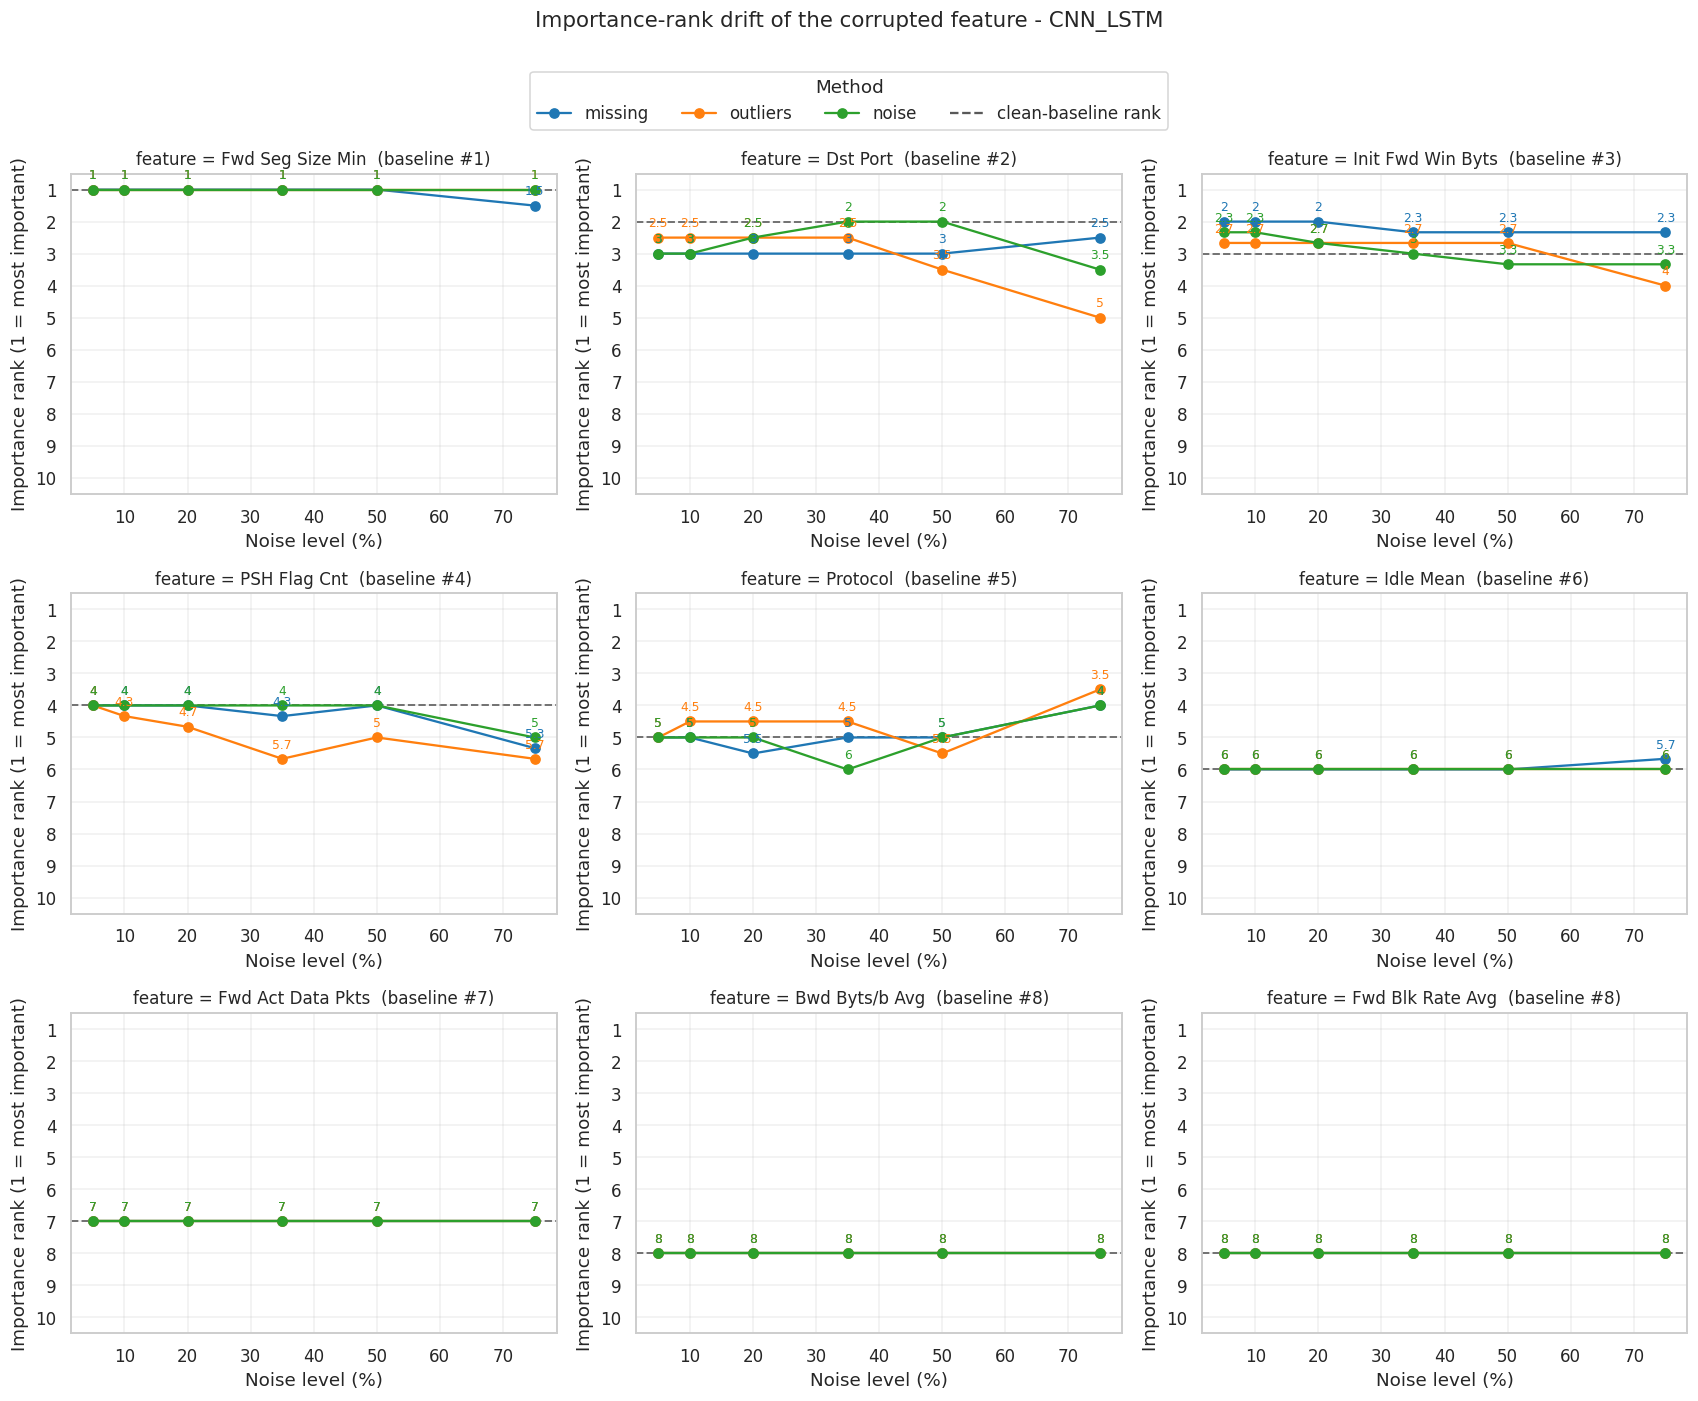

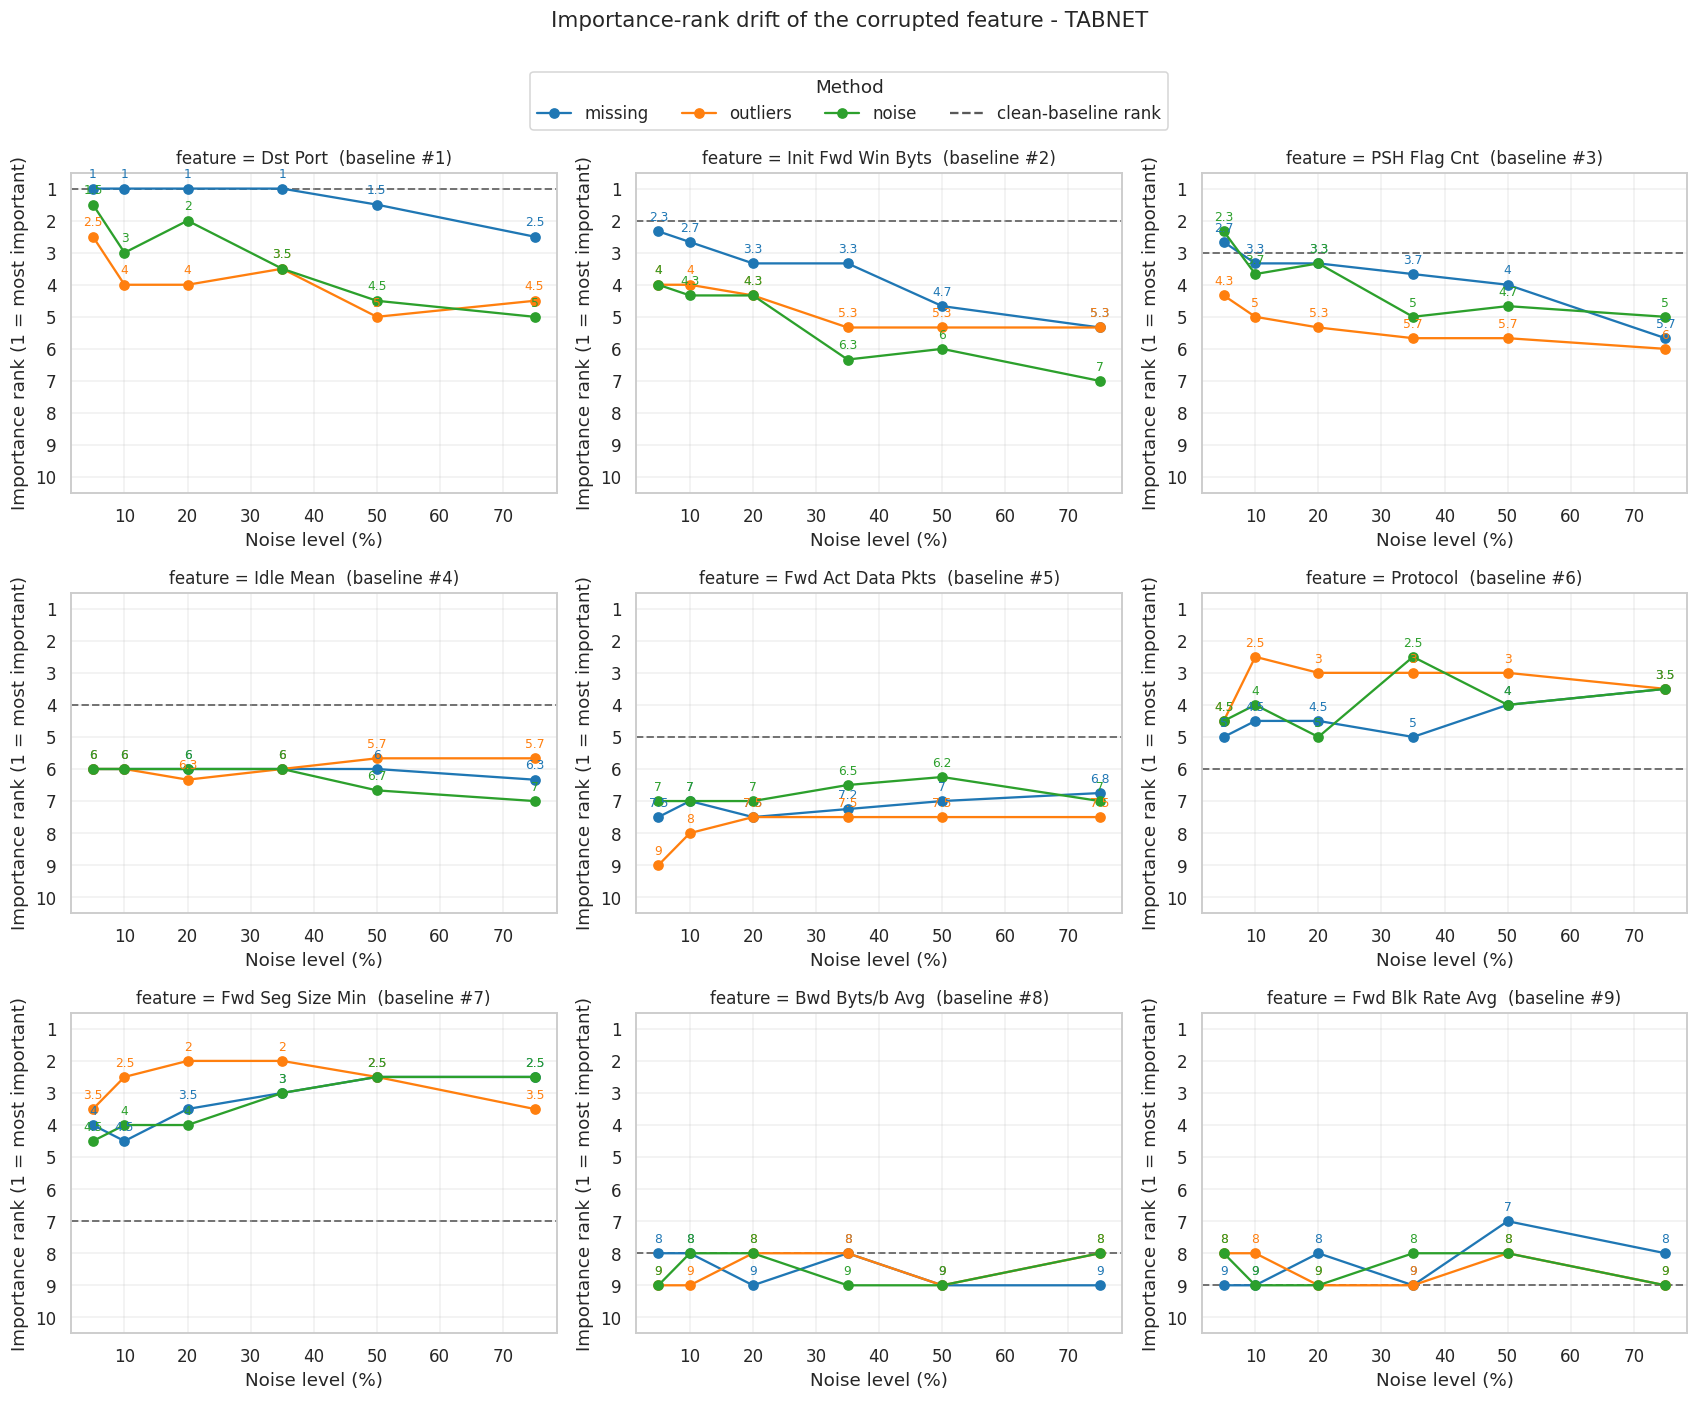

In [18]:
# fid was filtered to SCENARIO in section 9; build the clean-baseline ranks too.
bfi = eu.baseline_feature_importance(ROOT_DIR)
if 'fid' not in dir() or fid is None or fid.empty:
    print("No feature-importance data available yet.")
else:
    for model in sorted(fid["model"].dropna().unique()):
        save = (os.path.join(RESULTS_DIR, "figures", f"rank_drift_{model}.png")
                if SAVE_FIGURES else None)
        fig = eu.plot_feature_rank_drift(fid, model, baseline_fi=bfi, savepath=save)
        if fig is not None:
            plt.show()

## 10. Export for the thesis

Aggregated tables are written to CSV under `RESULTS_DIR` so they can be pulled
straight into the LaTeX sources in `temp-latex` (e.g. with `pandas.to_latex` or
`pgfplots`). Re-running regenerates them from whatever is currently on disk.

In [19]:
if HAS_DATA:
    for metric in ["mcc", "f1", "accuracy"]:
        eu.export_aggregate(df, metric, RESULTS_DIR, conf=CONF_LEVEL)
    if not sig_mcc.empty:
        sig_mcc.to_csv(os.path.join(RESULTS_DIR, "significance_mcc_binary_vs_lownoise.csv"),
                       index=False)
        print("[export] significance_mcc_binary_vs_lownoise.csv")
    if HAS_BASELINE and not bsig_mcc.empty:
        bsig_mcc.to_csv(os.path.join(RESULTS_DIR, "significance_mcc_binary_vs_baseline.csv"),
                        index=False)
        print("[export] significance_mcc_binary_vs_baseline.csv")
    if HAS_BASELINE:
        BL.to_csv(os.path.join(RESULTS_DIR, "baseline_metrics.csv"), index=False)
        print("[export] baseline_metrics.csv")
    print("\nExports written to:", RESULTS_DIR)

[export] mcc: 456 rows -> evaluation_results/Experiment_B-multi/aggregate_mcc.csv
[export] f1: 456 rows -> evaluation_results/Experiment_B-multi/aggregate_f1.csv
[export] accuracy: 456 rows -> evaluation_results/Experiment_B-multi/aggregate_accuracy.csv
[export] significance_mcc_binary_vs_lownoise.csv
[export] significance_mcc_binary_vs_baseline.csv
[export] baseline_metrics.csv

Exports written to: evaluation_results/Experiment_B-multi


## 11. Auto-generated summary &amp; conclusions

A programmatic digest of the key numbers &mdash; a *starting point* for the
chapter's prose, recomputed every run so it never goes stale. Treat it as
scaffolding to be edited into academic English, not as final text.

In [20]:
def auto_summary():
    if not HAS_DATA:
        print("No data yet - nothing to summarise.")
        return
    ref = eu.reference_level(df)
    lines = []
    lines.append(f"Experiment {PHASE} - automatic evaluation summary")
    lines.append("=" * 60)
    lines.append(f"Runs parsed        : {len(df)//2} artifacts "
                 f"({df['seed'].nunique()} seeds, models={sorted(df['model'].dropna().unique())})")
    if HAS_BASELINE:
        for model in sorted(BL['model'].dropna().unique()):
            bv = eu.baseline_value(BL, model, 'binary', 'mcc')
            lines.append(f"Clean baseline MCC : {bv:.3f}  ({model}, binary)")
    else:
        lines.append(f"Reference level    : {ref:g}% (no clean baseline on disk; proxy)")

    bb = eu.aggregate_with_ci(df[df.task == 'binary'],
                              ['model','method','feature','noise_percentage'], 'mcc')
    if not bb.empty:
        top = bb.sort_values('mean', ascending=False).iloc[0]
        lines.append("")
        lines.append(f"Best binary MCC    : {top['mean']:.3f} "
                     f"({top['model']}, {top['method']} on {top['feature']} "
                     f"@ {top['noise_percentage']:g}%, n={int(top['n'])})")

    if HAS_BASELINE:
        n_beat = 0
        for model in df['model'].dropna().unique():
            s = eu.baseline_delta_significance(df, BL, model, 'binary', 'mcc')
            if not s.empty:
                n_beat += int(((s['median_delta'] > 0) & s['significant']).sum())
        lines.append(f"Beat clean baseline: {n_beat} (model x method x feature x level) "
                     f"configurations significantly beat clean (Wilcoxon p<0.05)")
    n_imp = 0
    for model in df['model'].dropna().unique():
        s = eu.paired_delta_significance(df, model, 'binary', 'mcc', ref)
        if not s.empty:
            n_imp += int(((s['median_delta'] > 0) & s['significant']).sum())
    lines.append(f"Sig. vs {ref:g}% level : {n_imp} configs improve over the lowest noise level")
    print("\n".join(lines))

auto_summary()

Experiment B - automatic evaluation summary
Runs parsed        : 4558 artifacts (20 seeds, models=['cnn_lstm', 'tabnet'])
Clean baseline MCC : 0.737  (cnn_lstm, binary)
Clean baseline MCC : 0.883  (tabnet, binary)

Best binary MCC    : 0.885 (tabnet, noise on FwdActDataPkts+IdleMean+InitFwdWinByts @ 5%, n=20)
Beat clean baseline: 10 (model x method x feature x level) configurations significantly beat clean (Wilcoxon p<0.05)
Sig. vs 5% level : 2 configs improve over the lowest noise level


---

### Caveats to carry into the write-up

* **Scenario-scoped.** This notebook concerns **only** the `multi`-feature scenario;
  its companion notebook covers the other one. Conclusions drawn here should be
  stated as specific to this scenario (do not generalise single-feature findings
  to the multiple-feature setting or vice versa).
* **Clean baseline is a single deterministic run** (no seeds), so the
  vs-baseline test (6a) is a one-sample Wilcoxon over the noisy config's seed
  distribution against a fixed clean value &mdash; the primary "noise beats
  clean" evidence for the thesis.
* As seeds accumulate toward the full 20, re-run the notebook periodically &mdash;
  the confidence intervals will tighten and previously non-significant effects
  may cross into significance.